## Russian River – Visitor Center vs USGS Gauge Comparison

This notebook compares water-level records from the Jenner visitor-center gauge and the USGS gauge at the Russian River estuary mouth. It includes:

1. **Data retrieval** – USGS NWIS discharge (Hacienda, Austin Creek) and stage (Jenner) via `hydrofunctions`; visitor-center CSV files.
2. **Merging & QC** – join gauges on a common 15-min index; gap-fill short outages; unit conversions to metres (NAVD88).
3. **Gauge cross-calibration** – OLS, power-law, and piecewise-linear regressions relating visitor-center $h$ to USGS $h$, conditioned on discharge $Q$.
4. **LSTM exploration** – a simple LSTM predicting USGS $h$ from $(Q,\, h_{\text{visitor}})$.

In [1]:
# Start with the usual.

import hydrofunctions as hf
%matplotlib inline
hf.__version__


'0.2.4'

In [2]:
import matplotlib
import matplotlib.pyplot as plt
# from climata.usgs import DailyValueIO
import pandas as pd
from pandas.plotting import register_matplotlib_converters
import numpy as np

register_matplotlib_converters()
plt.style.use('ggplot')

import sys

root = '/Users/octaviacrompton/Projects/russian-river-seepage/'
sys.path.append('/Users/octaviacrompton/Projects/russian-river-seepage/src/')
sys.path.append("drive/MyDrive/estuaries_Jenner/scripts/")


In [3]:
plt.rcParams['figure.figsize'] = (12.0, 6.0)
for mod in ['plot_config', 'timeseries_functions']:
    if mod in sys.modules: 
        del sys.modules[mod] 

import plot_config
from timeseries import *
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

In [4]:
# Depending on the site, the USGS collects groundwater levels (‘72019’), stage (‘00065’), precipitation, and more!
# sus_sed_sites = hf.NWIS( stateCd='CA', parameterCd='72019', start_date='2018-02-03',);


### Get USGS gauge data

In [5]:
%%time
site_Hacienda = hf.NWIS( '11467000',  'iv', start_date='1900-04-26')

Requested data from https://nwis.waterservices.usgs.gov/nwis/iv/?format=json%2C1.1&sites=11467000&startDT=1900-04-26
CPU times: user 29.5 s, sys: 1.62 s, total: 31.1 s
Wall time: 2min 5s


In [6]:
Hacienda = site_Hacienda.df('data').rename(
    columns = {'USGS:11467000:00060:00000':'Q', }, 
    inplace = False)

Hacienda = Hacienda.loc[Hacienda.index.round('15min')]

In [7]:
cols = [col for col in Hacienda.columns if '63680' in col]
# site_Hacienda.df('data')[cols].isna().sum(0) 
cols

['USGS:11467000:63680-16452:00000', 'USGS:11467000:63680-226408:00000']

In [8]:

Hacienda['Turbidity'] = np.nanmedian(Hacienda[cols],1)

In [9]:
site_Jenner = hf.NWIS('11467270', 'iv', start_date='2018-04-26', parameterCd='00065')
site_Jenner

Requested data from https://nwis.waterservices.usgs.gov/nwis/iv/?format=json%2C1.1&sites=11467270&parameterCd=00065&startDT=2018-04-26


USGS:11467270: RUSSIAN R A HIGHWAY 1 BRIDGE NR JENNER CA
    00065-229225: <15 * Minutes>  Gage height, feet [NAVD88]
    00065-241826: <15 * Minutes>  Gage height, feet [NGVD29]
Start: 2018-04-26 23:15:00+00:00
End:   2026-04-02 20:30:00+00:00

### Read visitor center data

In [10]:
Jenner = site_Jenner.df('stage').rename(columns={'USGS:11467270:00065-229225:00000':'USGS_h'
                                                }, inplace=False)[['USGS_h']]
# unit conversions: https://pubs.usgs.gov/sir/2010/5040/section.html

# NAVD88 gage height in feet, multiply by 0.3048 to get meter

In [11]:
#  Jenner visitor center data
vc_dir = root + "data/visitor_center/"

Jenner2011 = pd.read_csv(vc_dir + 'Jenner_River_Gauge_2011.csv')
Jenner2012 = pd.read_csv(vc_dir + 'Jenner_River_Gauge_2012.csv')
Jenner2013 = pd.read_csv(vc_dir + 'Jenner_River_Gauge_2013.csv')
Jenner2014 = pd.read_csv(vc_dir + 'Jenner_River_Gauge_2014.csv')
Jenner2015 = pd.read_csv(vc_dir + 'Jenner_River_Gauge_2015.csv')
Jenner2016 = pd.read_csv(vc_dir + 'Jenner_River_Gauge_2016.csv')
Jenner2017 = pd.read_csv(vc_dir + 'Jenner_River_Gauge_2017.csv')
Jenner2018 = pd.read_csv(vc_dir + 'Jenner_River_Gauge_2018.csv')
Jenner2019 = pd.read_csv(vc_dir + 'Jenner_River_Gauge_2019.csv')
Jenner2020 = pd.read_csv(vc_dir + 'Jenner_River_Gauge_2020.csv')
Jenner2021 = pd.read_csv(vc_dir + 'Jenner_River_Gauge_2021.csv')
Jenner2022 = pd.read_csv(vc_dir + 'Jenner_River_Gauge_2022.csv')
Jenner2023 = pd.read_csv(vc_dir + 'Jenner_River_Gauge_2023.csv')

In [12]:
# Combine visitor center files
Jgauge = pd.concat([Jenner2011, Jenner2012, Jenner2013, Jenner2014, Jenner2015, Jenner2016, Jenner2017, 
                    Jenner2018, Jenner2019, Jenner2020, Jenner2021, Jenner2022, Jenner2023])
Jgauge = Jgauge.rename(
    {'Time (Local)' : 'Time', 'Channel 1 (Feet)' : 'Channel_1', ' Channel 2 ()': 'Channel_2'}, axis = 1)
Jgauge['Time'] = pd.to_datetime(Jgauge['Time'])
# Jgauge['date'] = Jgauge.Time.dt.date

Jgauge = Jgauge.set_index(Jgauge.Time)[['Channel_1']].tz_localize('US/Pacific', ambiguous = True).tz_convert("UCT")
Jgauge.head()


,Channel_1
Time,
2011-08-23 16:30:00+00:00,-8.37
2011-08-23 16:45:00+00:00,-8.41
2011-08-30 17:30:00+00:00,-8.41
2011-08-30 17:45:00+00:00,-8.41
2011-08-30 18:00:00+00:00,1.35


In [13]:
# hourly = Jenner.drop('NGVD29', axis = 1)
hourly = Jenner.join(Hacienda[['Turbidity', 'Q']], how='outer')

hourly['USGS_h'] = hourly['USGS_h']*0.3048 # confert to meters, NAVD88
hourly['Q'] = hourly['Q']*0.0283168 # convert cfs to m3/s

hourly = hourly.join(Jgauge, how='outer')
hourly = hourly.rename({"Channel_1" : 'visitor_h'}, axis = 1)
hourly.loc[hourly['visitor_h'] < -3, 'visitor_h'] = np.nan

# convert to meters
hourly['visitor_h']  = hourly['visitor_h']*0.3048 + 2.73*0.3048
start_usgs = hourly.query("visitor_h > 0").index[0]
end_usgs = hourly.query("visitor_h > 0").index[-1]

hourly = hourly.loc[start_usgs:end_usgs]
hourly = hourly.groupby(hourly.index).mean()

In [14]:
# 
result = sequence_lengths(hourly.visitor_h.isna())
# add closure lengths to merged
hourly['visitor_gap'] = result
hourly['visitor_filled'] = hourly['visitor_h'].interpolate(method='polynomial', order=1)
hourly.loc[hourly.query('visitor_gap > 24').index, 'visitor_filled'] = np.nan

<Axes: xlabel='datetimeUTC'>

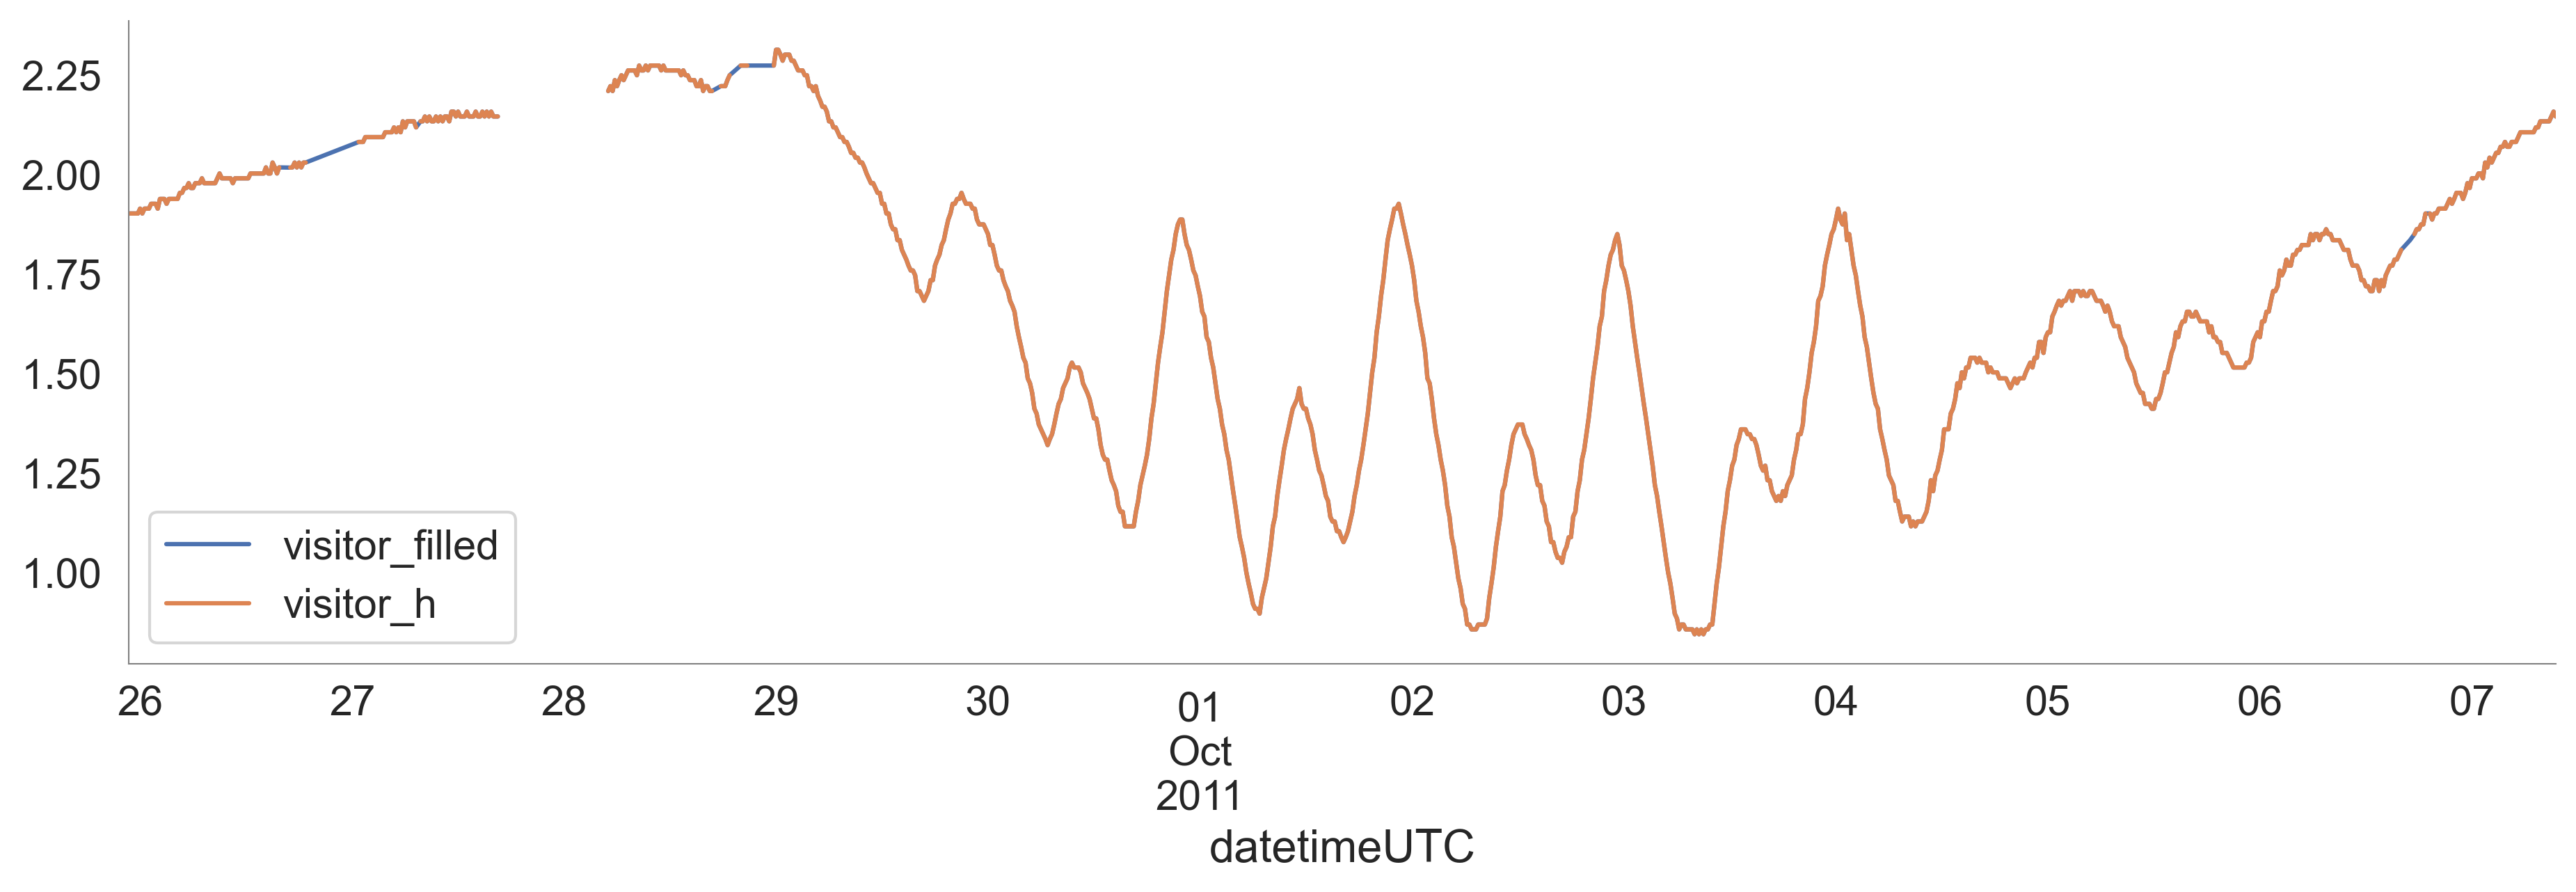

In [15]:

fig, ax = plt.subplots(1, figsize = (15, 4))
start_ind = np.where((hourly['visitor_gap'] > 1) & (hourly['visitor_gap'] < 24) )[0][100]

hourly[[ 'visitor_filled','visitor_h',]][start_ind - 100:start_ind + 1000].plot(ax = ax)

<Axes: xlabel='datetimeUTC'>

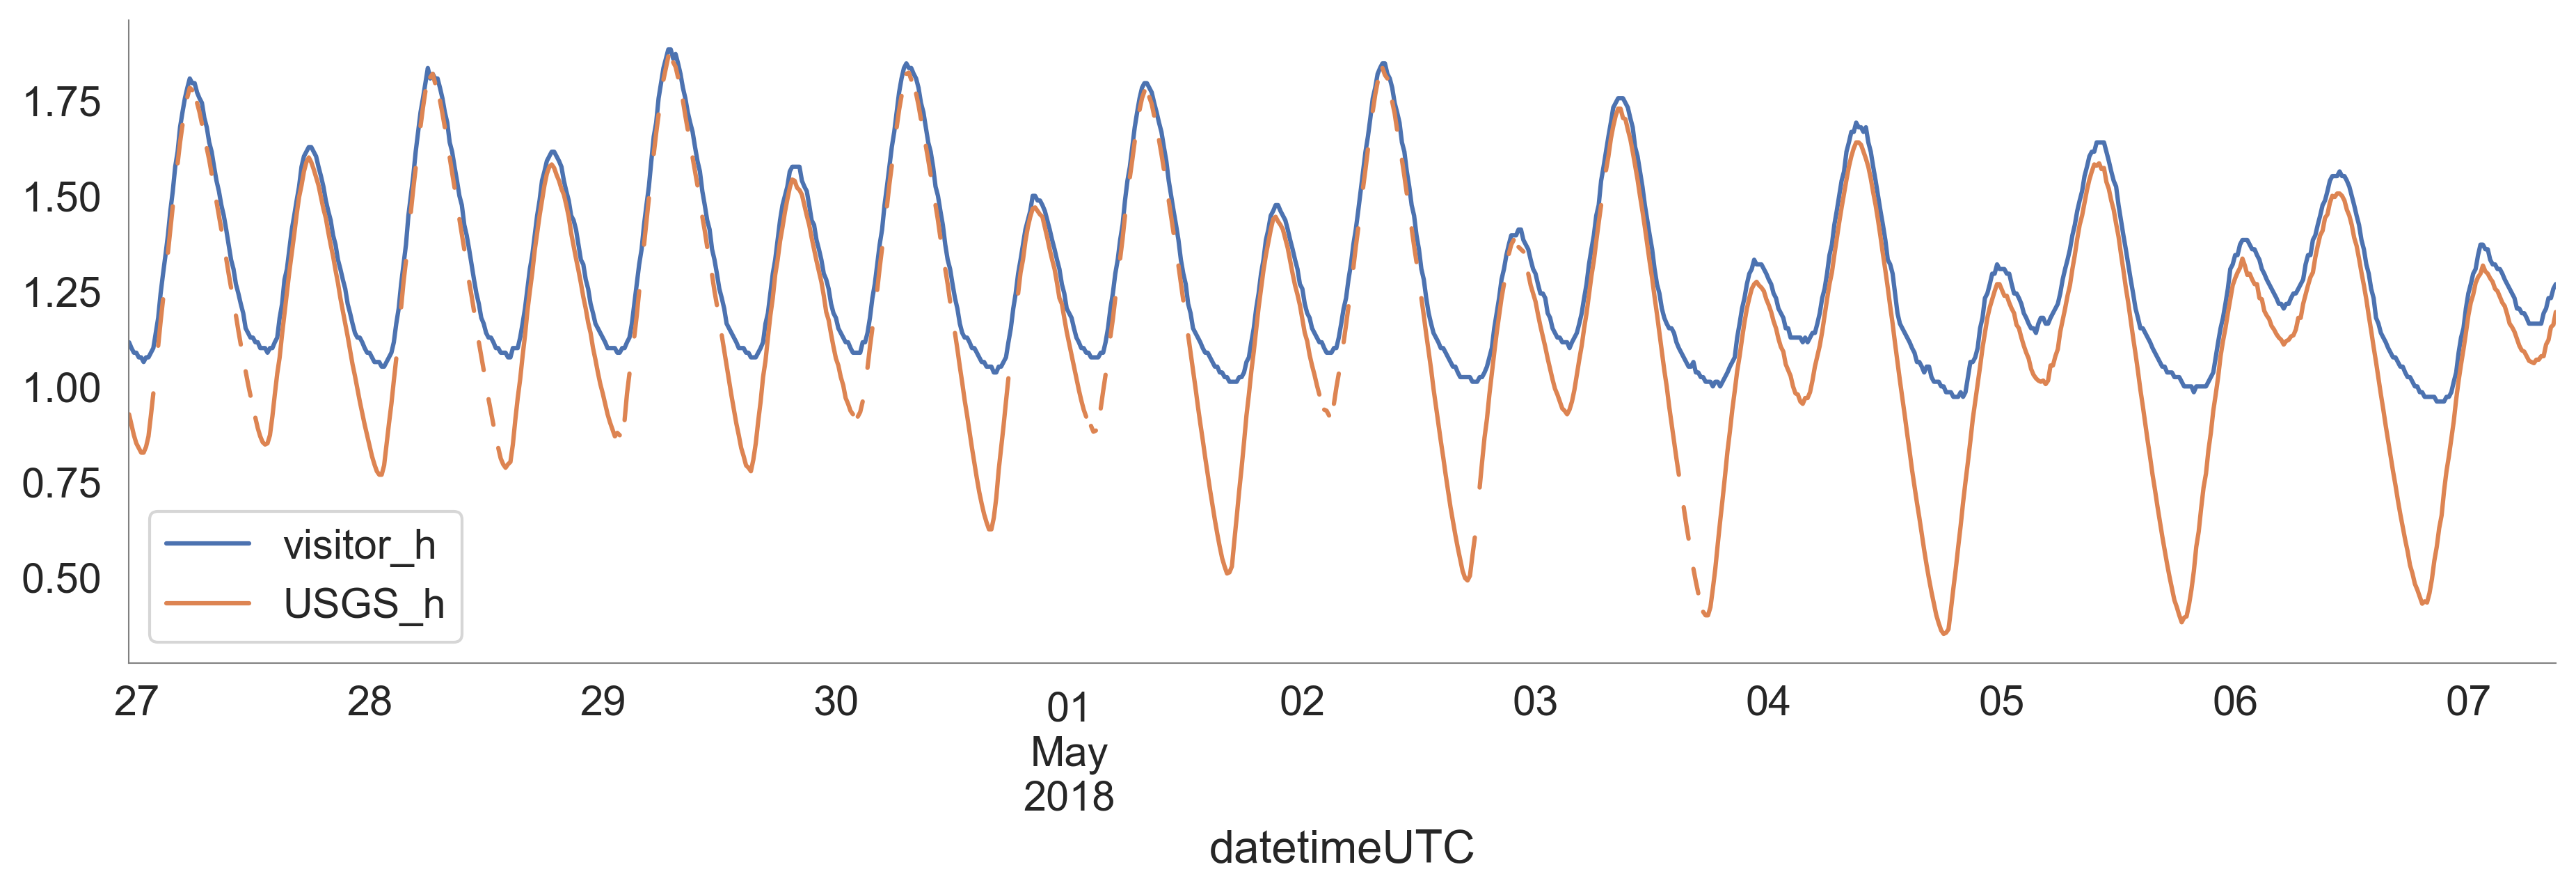

In [16]:
start_ind = np.where(hourly.USGS_h > 0)[0][0]

fig, ax = plt.subplots(1, figsize = (15, 4))
hourly[['visitor_h', 'USGS_h']][start_ind:start_ind + 1000].plot(ax = ax)

### Relating visitor center to USGS gauge data

In [17]:
def fit_power_law(subset, target = 'curve', 
                cols = ['fV', 'phi_veg', 'p', ], train_test = 0):
    """
    Fit equation:
       log (y) = a log(x_1) + b log(x_2)   
    
    """
    from sklearn.model_selection import train_test_split

    data = np.log(subset[[target]].astype(float))
    
    for col in cols:
        data[col] = np.log(subset[col].astype(float))


    res = smf.ols(formula= '{0} ~ {1}'.format(target, '+'.join(cols)), data=data).fit()

    data['y_hat'] = res.predict(data[cols]) 

    return res

def fit_linear(subset, target = 'curve', 
                cols = ['fV', 'phi_veg', 'p', ], train_test = 0):
    '''
    Fit equation:
       log (y) = a log(x_1) + b log(x_2)   
    
    '''
    from sklearn.model_selection import train_test_split
 
    data = (subset[[target]+ cols].astype(float))
    
    res = smf.ols(formula= '{0} ~ 1 + {1}'.format(target, '+'.join(cols)), data=data).fit()

    data['y_hat'] = res.predict(data[cols]) 

    return res

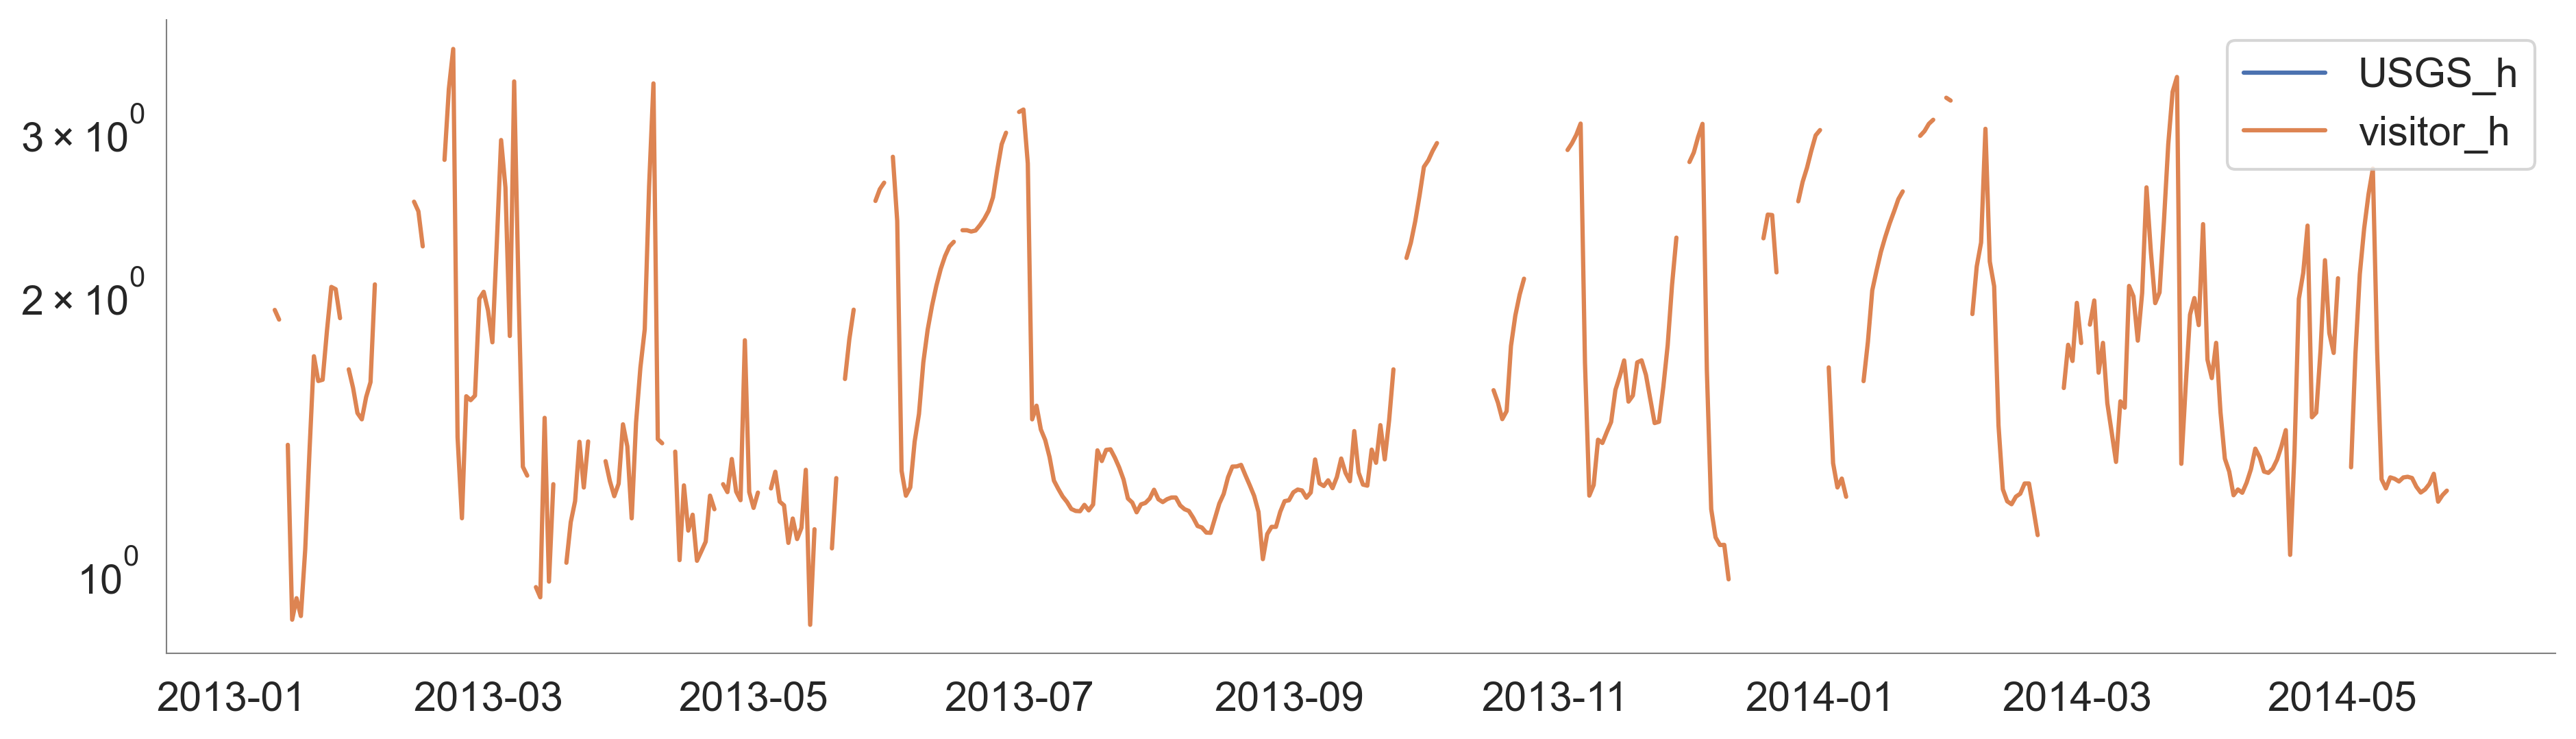

In [18]:
fig, ax = plt.subplots(1, figsize = (15, 4))
hourly.groupby(hourly.index.date).mean()[['USGS_h', 'visitor_h']][500:1000].plot(ax = ax)
ax.set_yscale('log')

<Axes: >

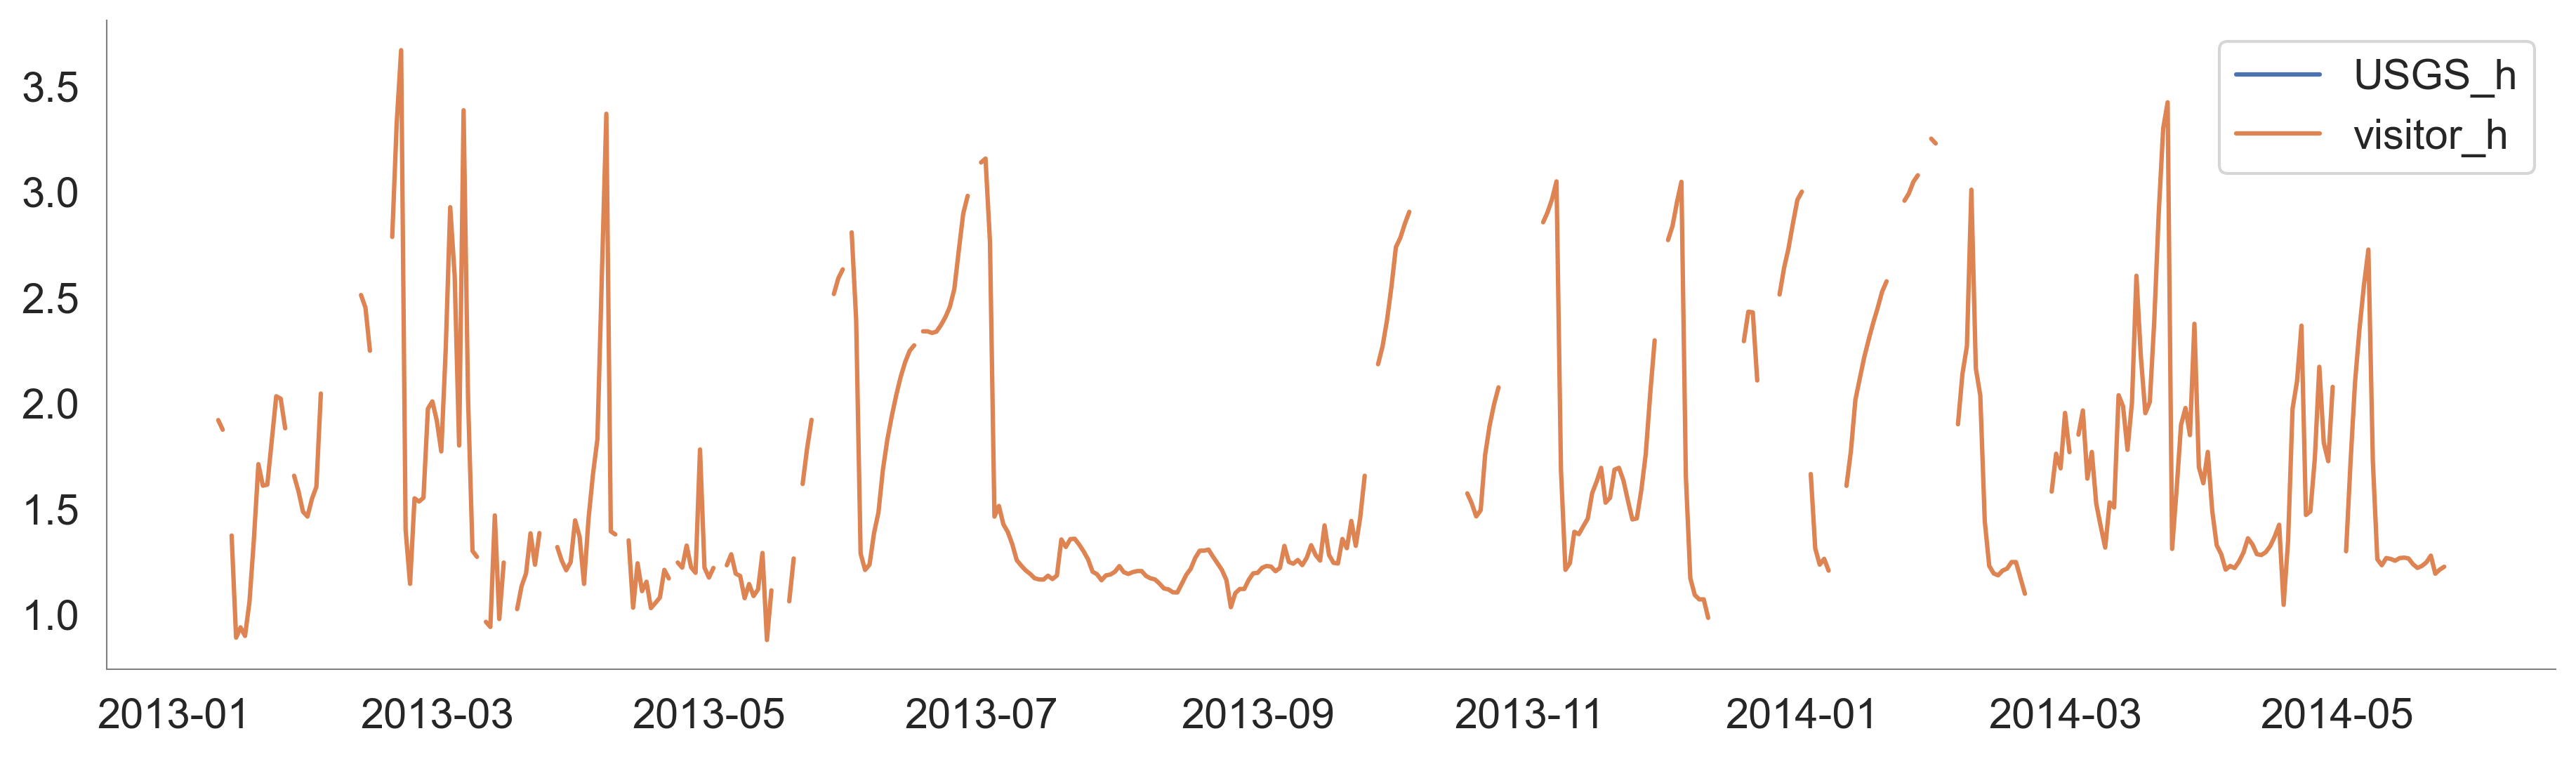

In [19]:
fig, ax = plt.subplots(1, figsize = (15, 4))
hourly.groupby(hourly.index.date).mean()[['USGS_h', 'visitor_h']][500:1000].plot(ax = ax)


In [20]:
import sklearn
import statsmodels.api as sm
import statsmodels.formula.api as smf

subset = hourly.query('visitor_h>0').sample(20000)
xvars =  ['visitor_h','Q']
res_pl = fit_power_law(subset, target = 'visitor_h',   cols =xvars, train_test = 0)
# res.summary()


Intercept   -7.027390e-15
visitor_h    1.000000e+00
Q            5.946509e-17
dtype: float64 1.0


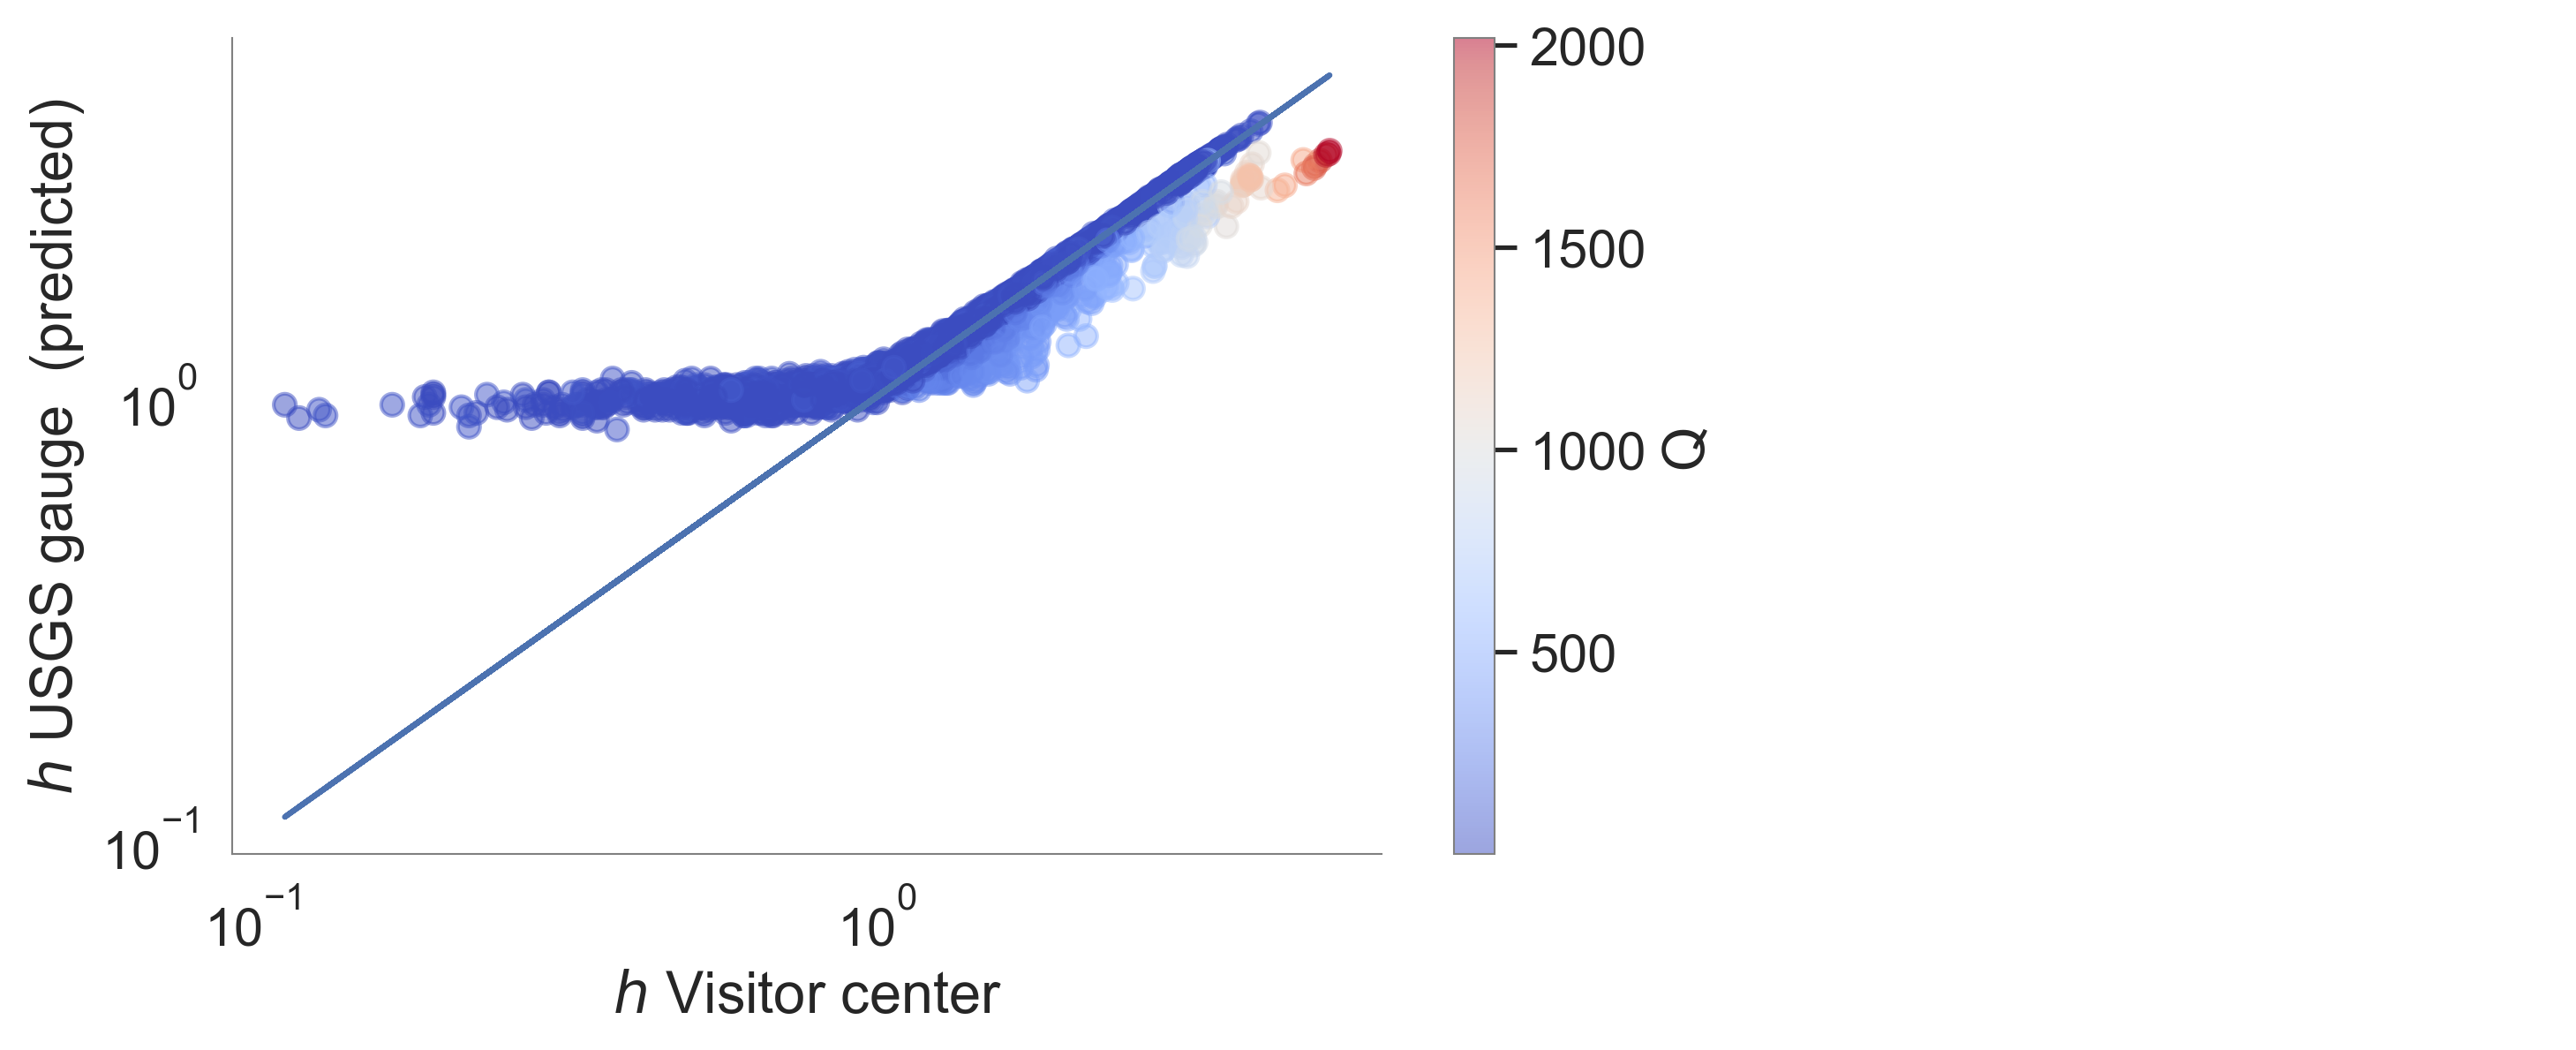

In [21]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

fig = plt.figure(figsize = (7,4))
plt.scatter(subset['USGS_h'], np.exp(res_pl.predict(np.log(subset[xvars]))),
            c = subset['Q'], alpha = 0.5,  cmap = 'coolwarm')
plt.colorbar(label = "Q")
ax = plt.gca()
ax.plot(subset.USGS_h, subset.USGS_h)
ax.set_xlabel("$h$ Visitor center")
ax.set_ylabel("$h$ USGS gauge  (predicted)")
ax.set_xscale('log')
ax.set_yscale('log')

ax.text(2, 1., ' ', transform=ax.transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic')
print (res_pl.params, res_pl.rsquared_adj)

In [22]:
subset = hourly.sample(20000)
sampled = subset.sort_values("Q")

(Intercept   -0.194202
 visitor_h    1.070678
 Q            0.000861
 dtype: float64,
 0.9690811330382977)

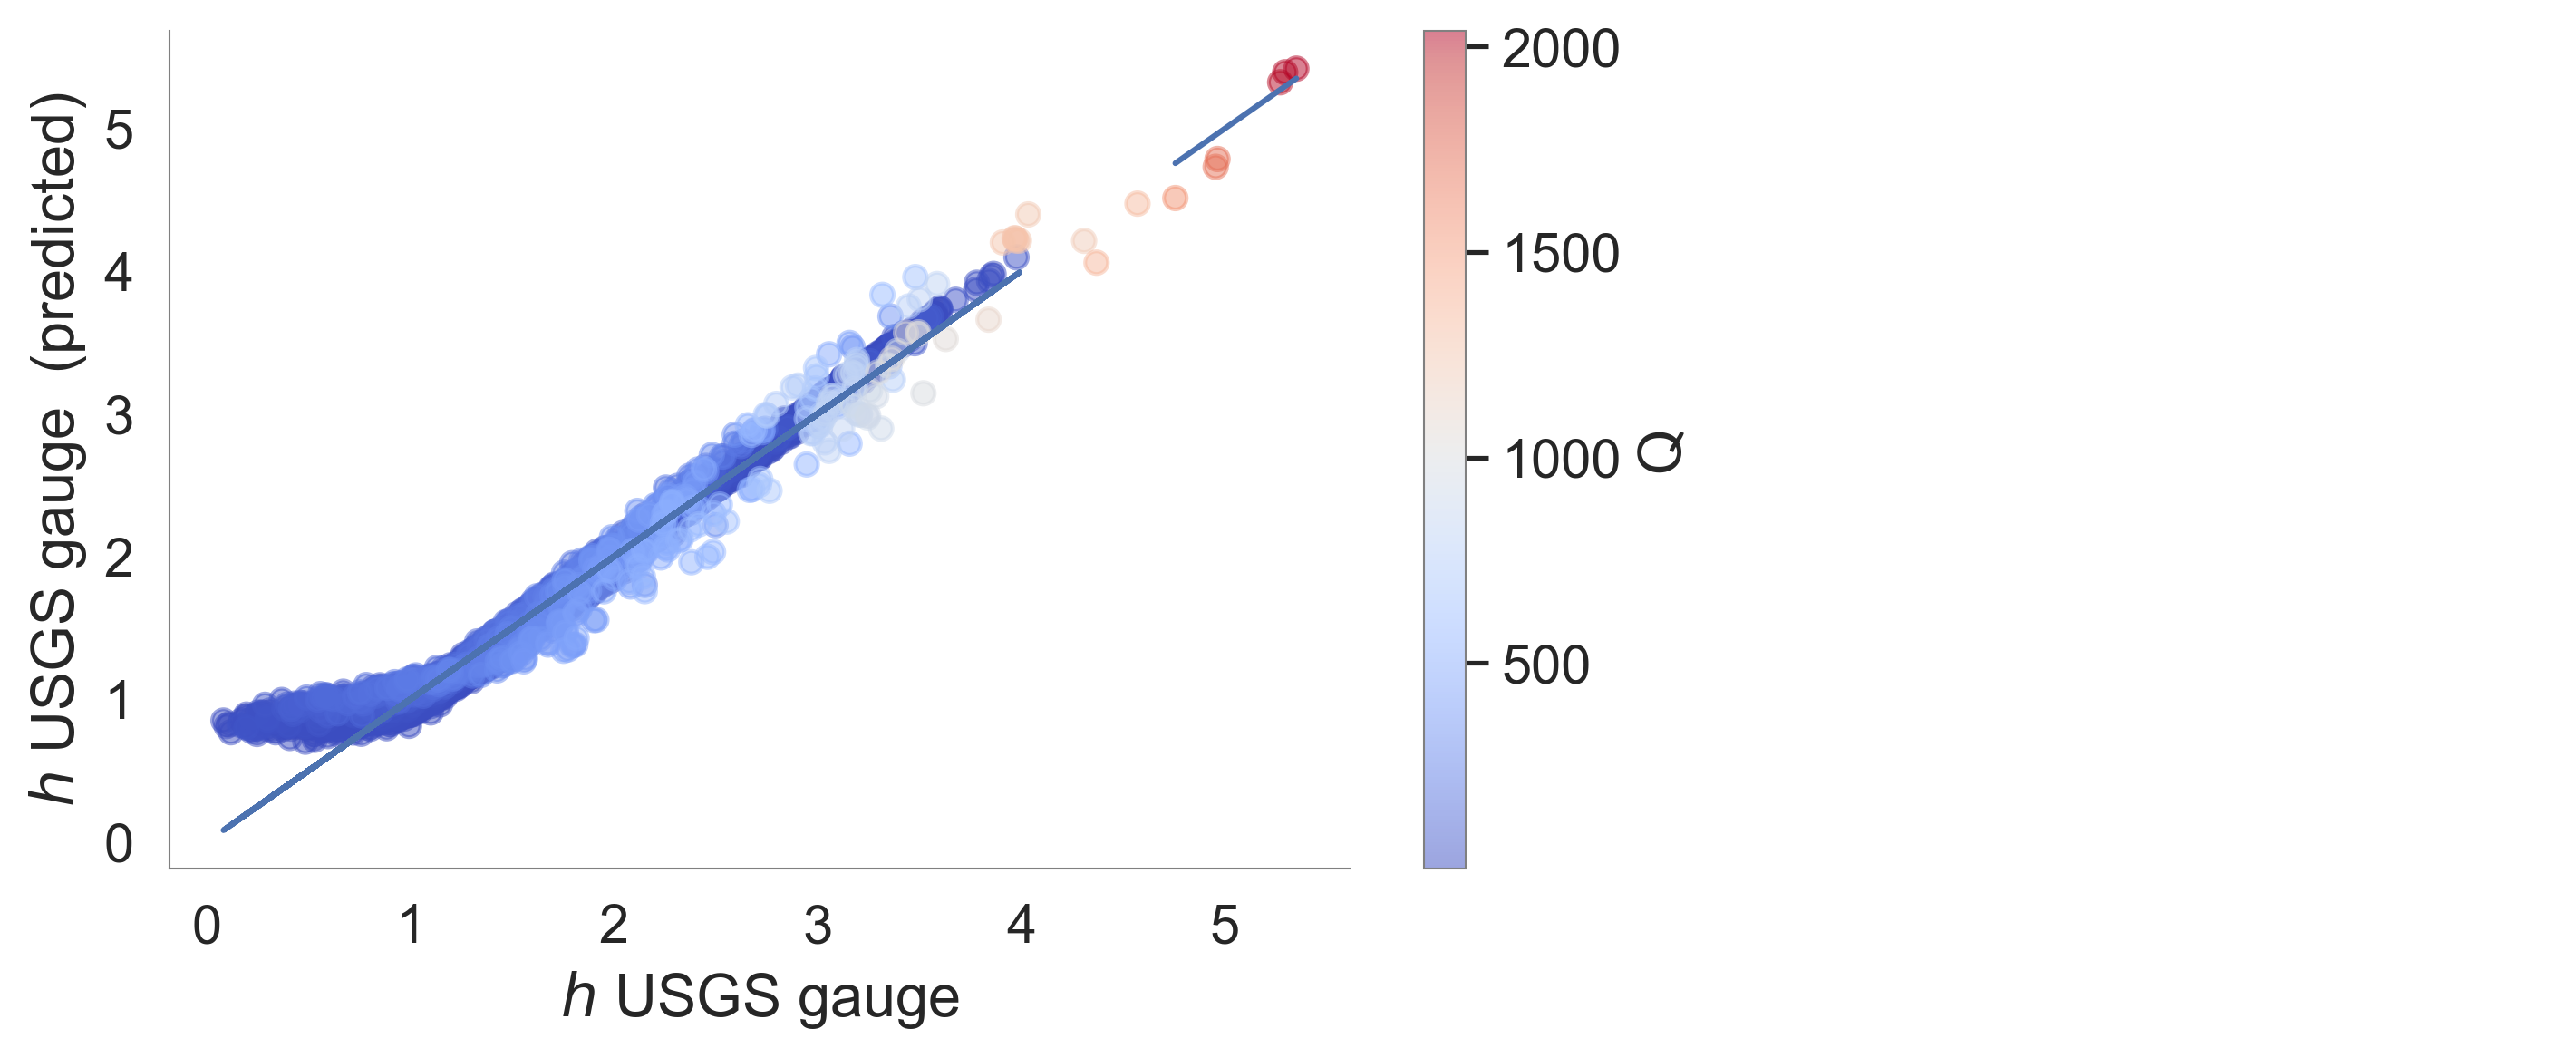

In [23]:
res = fit_linear(sampled, target = 'USGS_h',  cols = xvars)

fig = plt.figure(figsize = (7,4))
plt.scatter(sampled['USGS_h'], (res.predict(sampled[xvars])), c = sampled['Q'], alpha = 0.5,  cmap = 'coolwarm')
plt.colorbar(label = "Q")
ax = plt.gca()
ax.plot(sampled.USGS_h, sampled.USGS_h)
ax.set_xlabel("$h$ USGS gauge")
ax.set_ylabel("$h$ USGS gauge  (predicted)")
# ax.set_xscale('log')
# ax.set_yscale('log')
res.params['visitor_h'], res.rsquared_adj
ax.text(2, 1., ' ', transform=ax.transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic')
res.params, res.rsquared_adj

Text(2, 1.0, ' ')

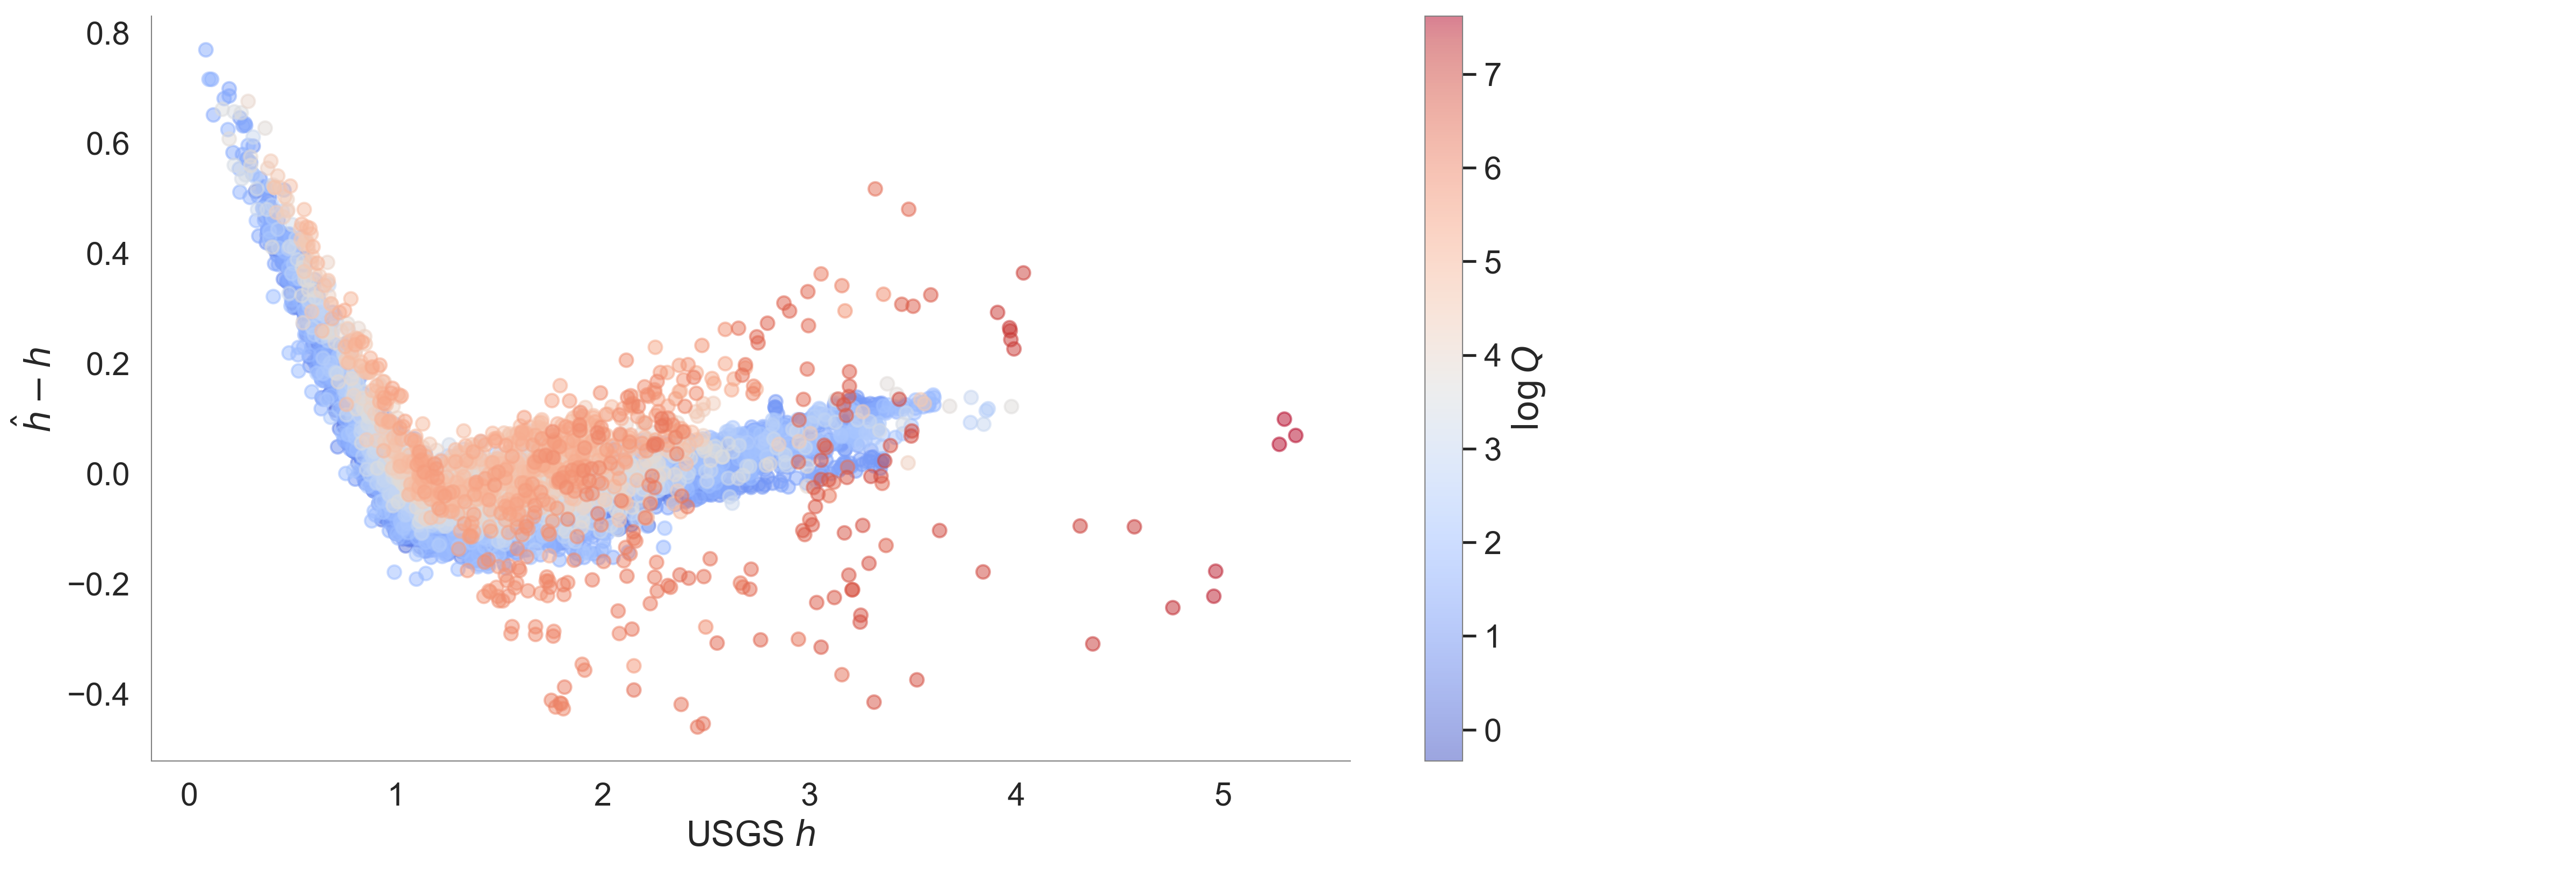

In [24]:
c = plt.scatter(sampled['USGS_h'], res.predict(sampled[xvars])- sampled['USGS_h'], 
            c = np.log(sampled['Q']), alpha = 0.5, cmap = 'coolwarm')
plt.colorbar(c,label = "$\log Q$")
res.summary()
ax = plt.gca()

ax.set_ylabel("$\hat h -h$ ")
ax.set_xlabel( 'USGS $h$')
# ax.set_xscale('log')
# ax.set_yscale('log')
ax.text(2, 1., ' ', transform=ax.transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic')

1.12776


Text(2, 1.0, ' ')

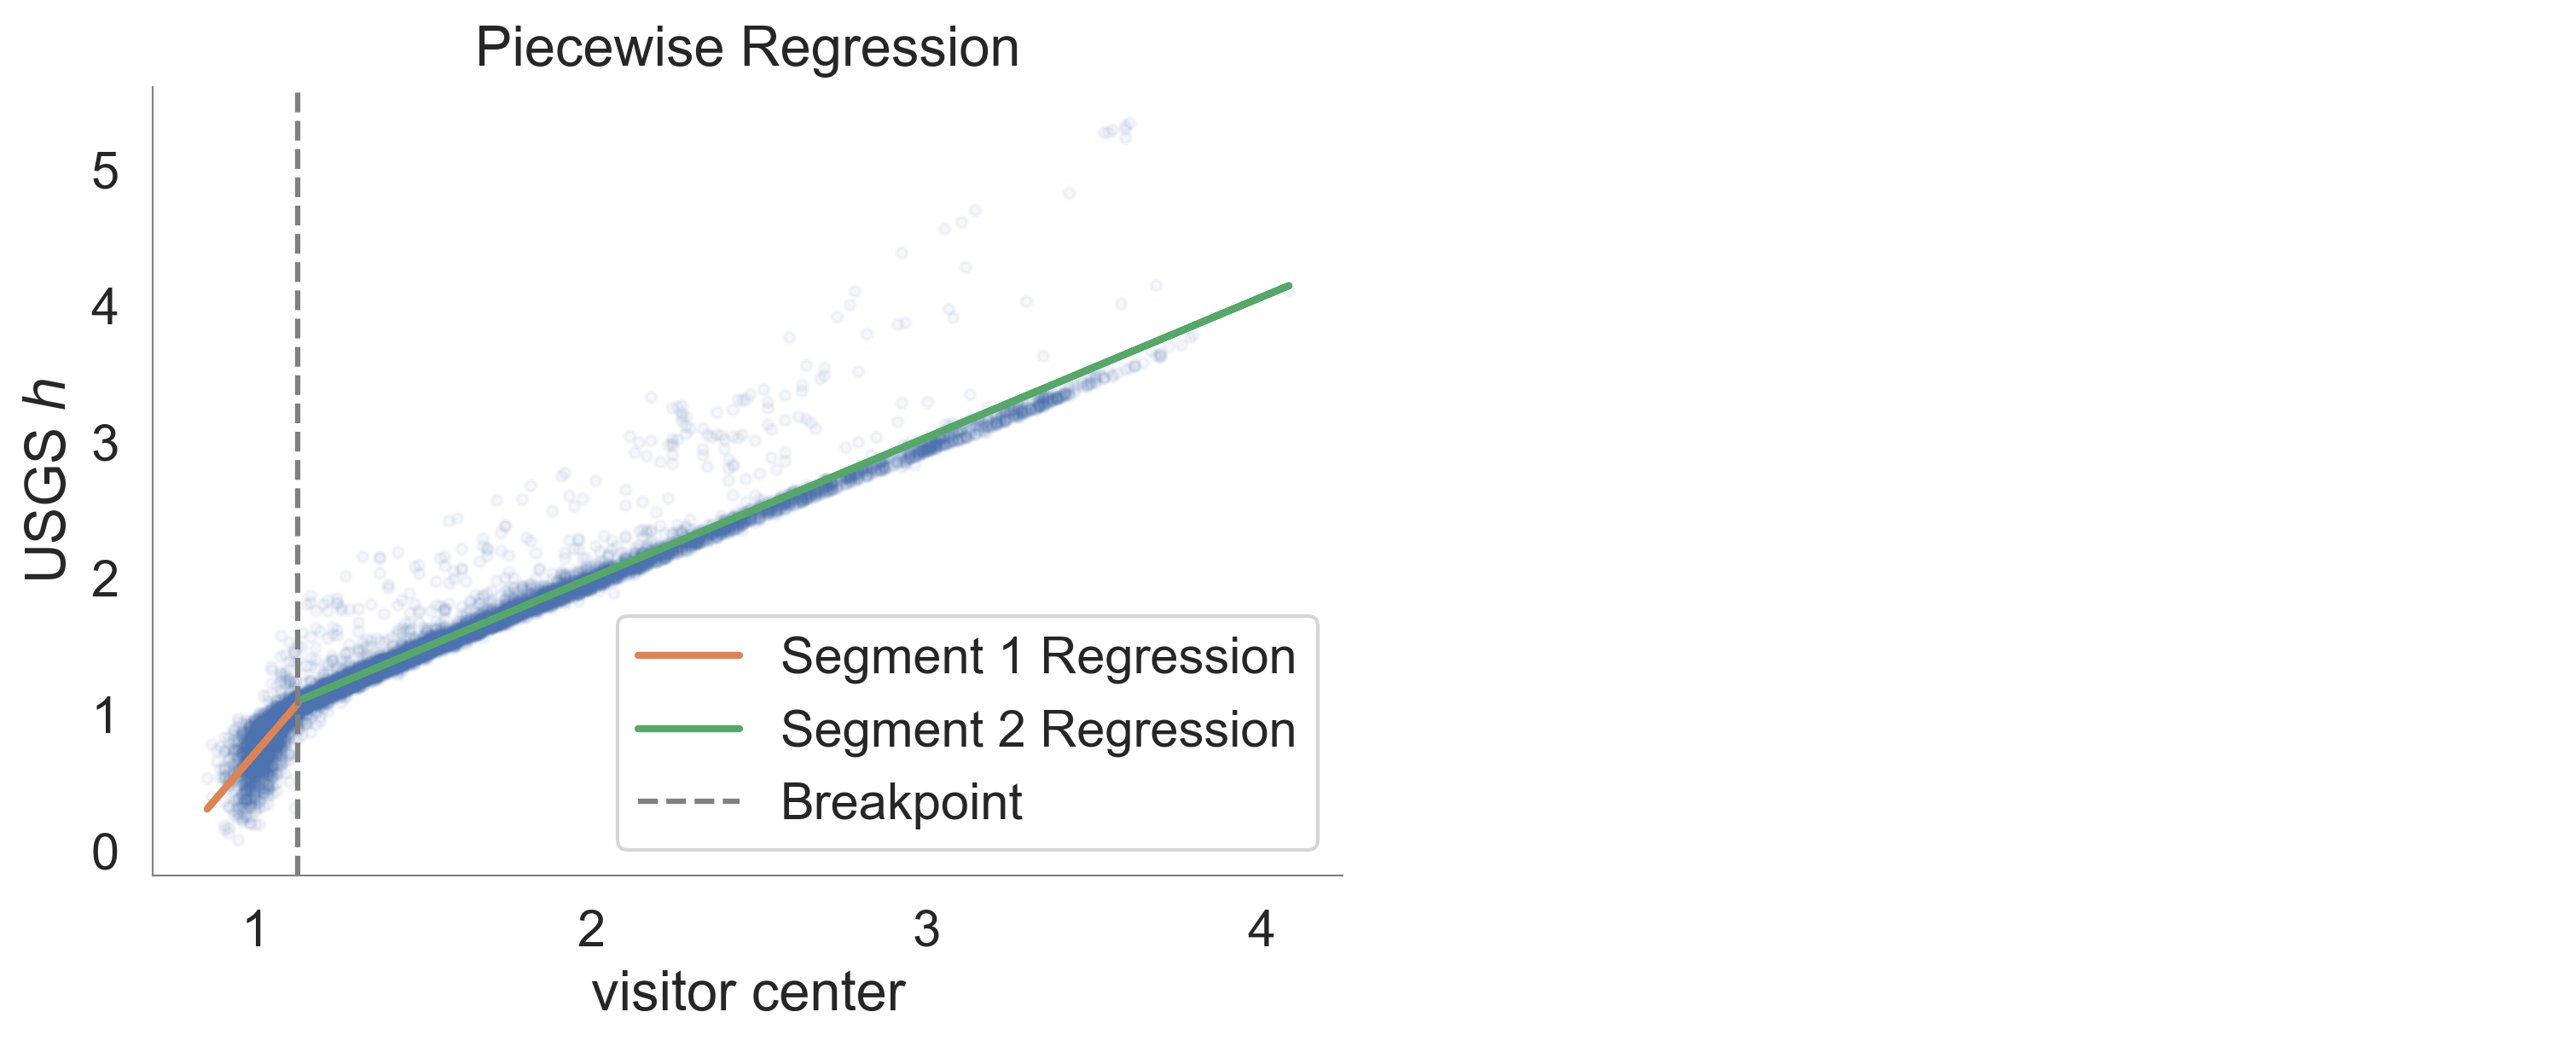

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Sample dataframe
df = hourly.dropna().sample(10000)

def compute_rss_for_breakpoint(breakpoint, df):
    df1 = df[df['visitor_h'] <= breakpoint]
    df2 = df[df['visitor_h'] > breakpoint]

    if len(df1) < 2 or len(df2) < 2:  # ensure there's enough data in each segment
        return np.inf

    reg1 = LinearRegression().fit(df1[['visitor_h']], df1['USGS_h'])
    reg2 = LinearRegression().fit(df2[['visitor_h']], df2['USGS_h'])

    rss1 = ((df1['USGS_h'] - reg1.predict(df1[['visitor_h']]))**2).sum()
    rss2 = ((df2['USGS_h'] - reg2.predict(df2[['visitor_h']]))**2).sum()

    return rss1 + rss2

# Identify the optimal breakpoint
potential_breakpoints = df['visitor_h'].unique()[1:-1][::2]  # exclude the first and last points
rss_values = [compute_rss_for_breakpoint(bp, df) for bp in potential_breakpoints]
optimal_breakpoint = potential_breakpoints[np.argmin(rss_values)]
print (optimal_breakpoint)
# Fit segmented regression using the optimal breakpoint
df1 = df[df['visitor_h'] <= optimal_breakpoint]
df2 = df[df['visitor_h'] > optimal_breakpoint]
reg1 = LinearRegression().fit(df1[['visitor_h']], df1['USGS_h'])
reg2 = LinearRegression().fit(df2[['visitor_h']], df2['USGS_h'])

plt.figure(figsize = (6,4))
# Visualize the results
plt.plot(df['visitor_h'], df['USGS_h'], '.', alpha = 0.05, label='')
plt.plot(df1['visitor_h'], reg1.predict(df1[['visitor_h']]), lw = 2, label='Segment 1 Regression')
plt.plot(df2['visitor_h'], reg2.predict(df2[['visitor_h']]),lw = 2,
          label='Segment 2 Regression')
plt.axvline(x=optimal_breakpoint, color='grey', linestyle='--', label='Breakpoint')
plt.xlabel('visitor center')
plt.ylabel('USGS $h$')
plt.legend()
plt.title('Piecewise Regression')
ax= plt.gca()
ax.text(2, 1., ' ', transform=ax.transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic')


Text(1.8, 1.0, ' ')

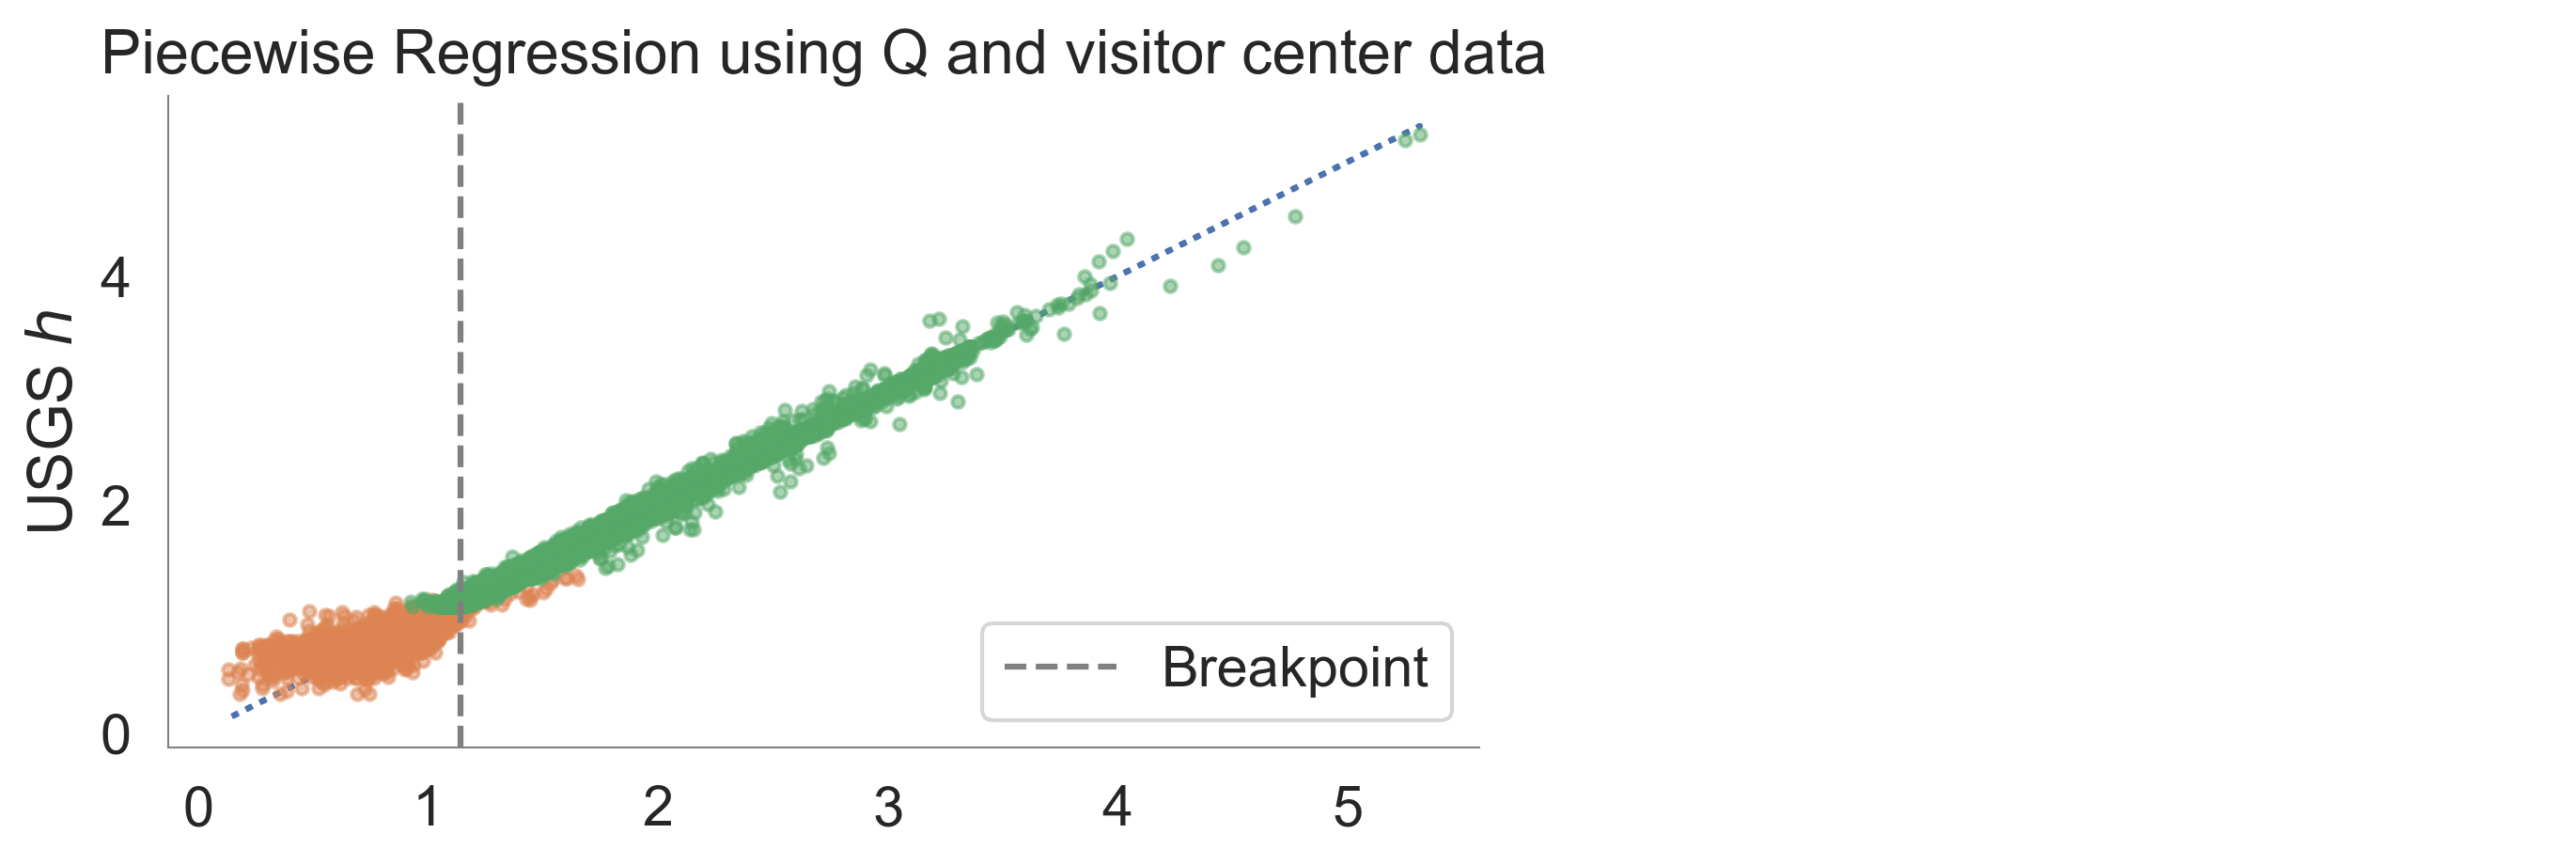

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def compute_rss_for_breakpoint(breakpoint, df, x_cols, y_col='USGS_h'):
    df1 = df[df[X1] <= breakpoint]
    df2 = df[df[X1] > breakpoint]

    if len(df1) < 2 or len(df2) < 2:  # ensure there's enough data in each segment
        return np.inf

    reg1 = LinearRegression().fit(df1[x_cols], df1[y_col])
    reg2 = LinearRegression().fit(df2[x_cols], df2[y_col])

    rss1 = ((df1[y_col] - reg1.predict(df1[x_cols]))**2).sum()
    rss2 = ((df2[y_col] - reg2.predict(df2[x_cols]))**2).sum()

    return rss1 + rss2

X1 = 'visitor_h'
X2 = 'Q'
x_columns = [ X1, X2]  # Add other predictor columns as needed

df = hourly.dropna().sample(10000)
# Identify the breakpoint for X1
potential_breakpoints = df[X1].unique()[1:-1]
rss_values = [compute_rss_for_breakpoint(bp, df, x_columns) for bp in potential_breakpoints]
optimal_breakpoint = potential_breakpoints[np.argmin(rss_values)]

# Fit segmented regression using the breakpoint
df1 = df[df[X1] <= optimal_breakpoint]
df2 = df[df[X1] > optimal_breakpoint]
reg1 = LinearRegression().fit(df1[x_columns], df1['USGS_h'])
reg2 = LinearRegression().fit(df2[x_columns], df2['USGS_h'])

plt.figure(figsize = (6,3))
# Visualize the results for USGS_h
plt.plot(df['USGS_h'], df['USGS_h'], ':')
plt.plot(df1['USGS_h'], reg1.predict(df1[x_columns]), '.',  alpha = 0.5)
plt.plot(df2['USGS_h'], reg2.predict(df2[x_columns]), '.',  alpha = 0.5)
plt.axvline(x=optimal_breakpoint, color='grey', linestyle='--', label='Breakpoint')
plt.ylabel('predicted USGS $h$')
plt.ylabel('USGS $h$')
plt.legend()
plt.title('Piecewise Regression using Q and visitor center data')

ax= plt.gca()
ax.text(1.8, 1., ' ', transform=ax.transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic')


In [27]:
optimal_breakpoint

1.139952

Text(1.8, 1.0, ' ')

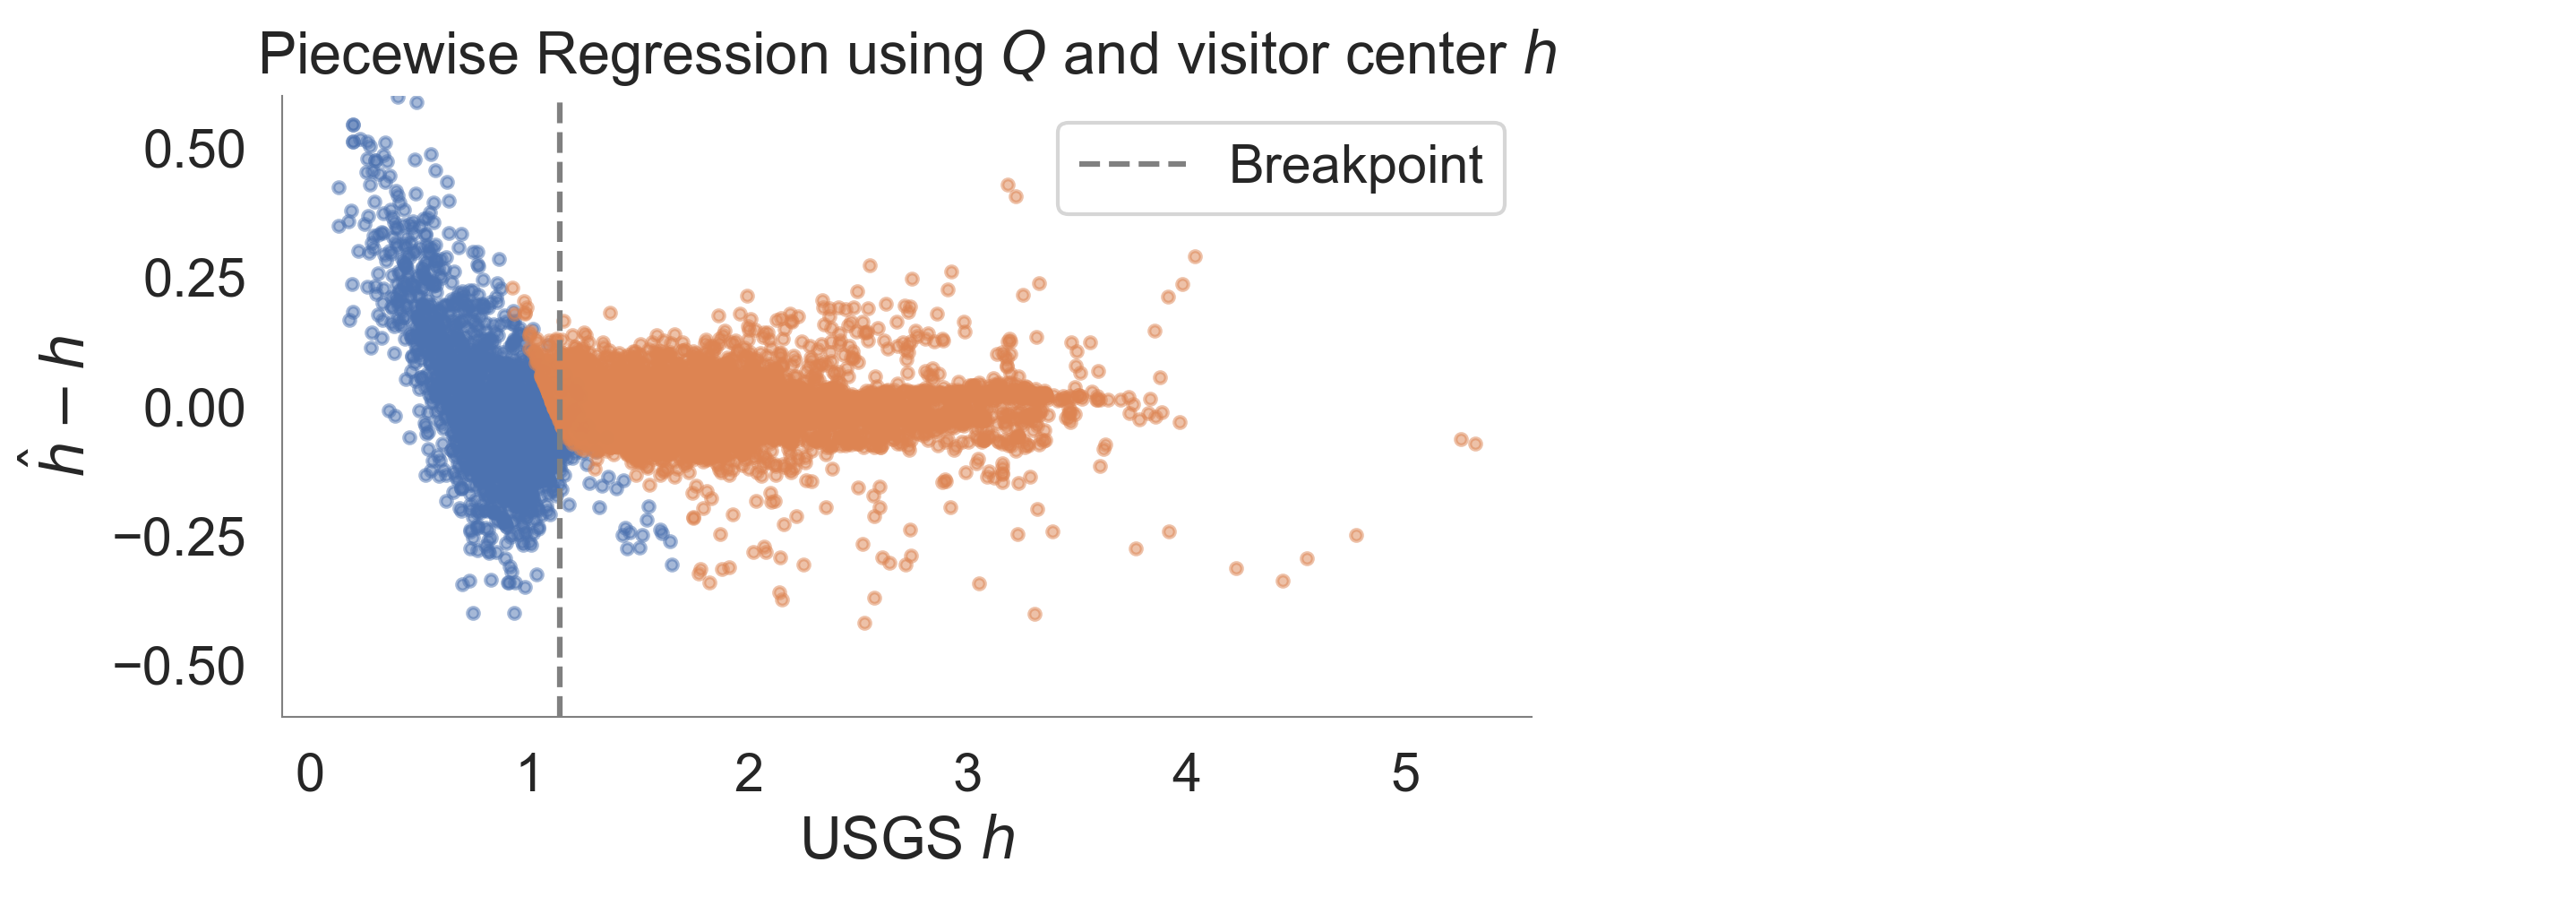

In [28]:
# Visualize the results for USGS_h
plt.figure(figsize= (6, 3))
plt.plot(df1['USGS_h'], reg1.predict(df1[x_columns]) - df1['USGS_h'], '.',  alpha = 0.5)
plt.plot(df2['USGS_h'], reg2.predict(df2[x_columns])- df2['USGS_h'], '.',  alpha = 0.5)
plt.axvline(x=optimal_breakpoint, color='grey', linestyle='--', label='Breakpoint')
plt.ylabel('$\hat h - h$')
plt.xlabel('USGS $h$')
plt.legend()
plt.title('Piecewise Regression using $Q$ and visitor center $h$')
plt.ylim(-0.6, 0.6)

ax= plt.gca()
ax.text(1.8, 1., ' ', transform=ax.transAxes, ha="left", va="top",
        fontsize = 18, style = 'italic')


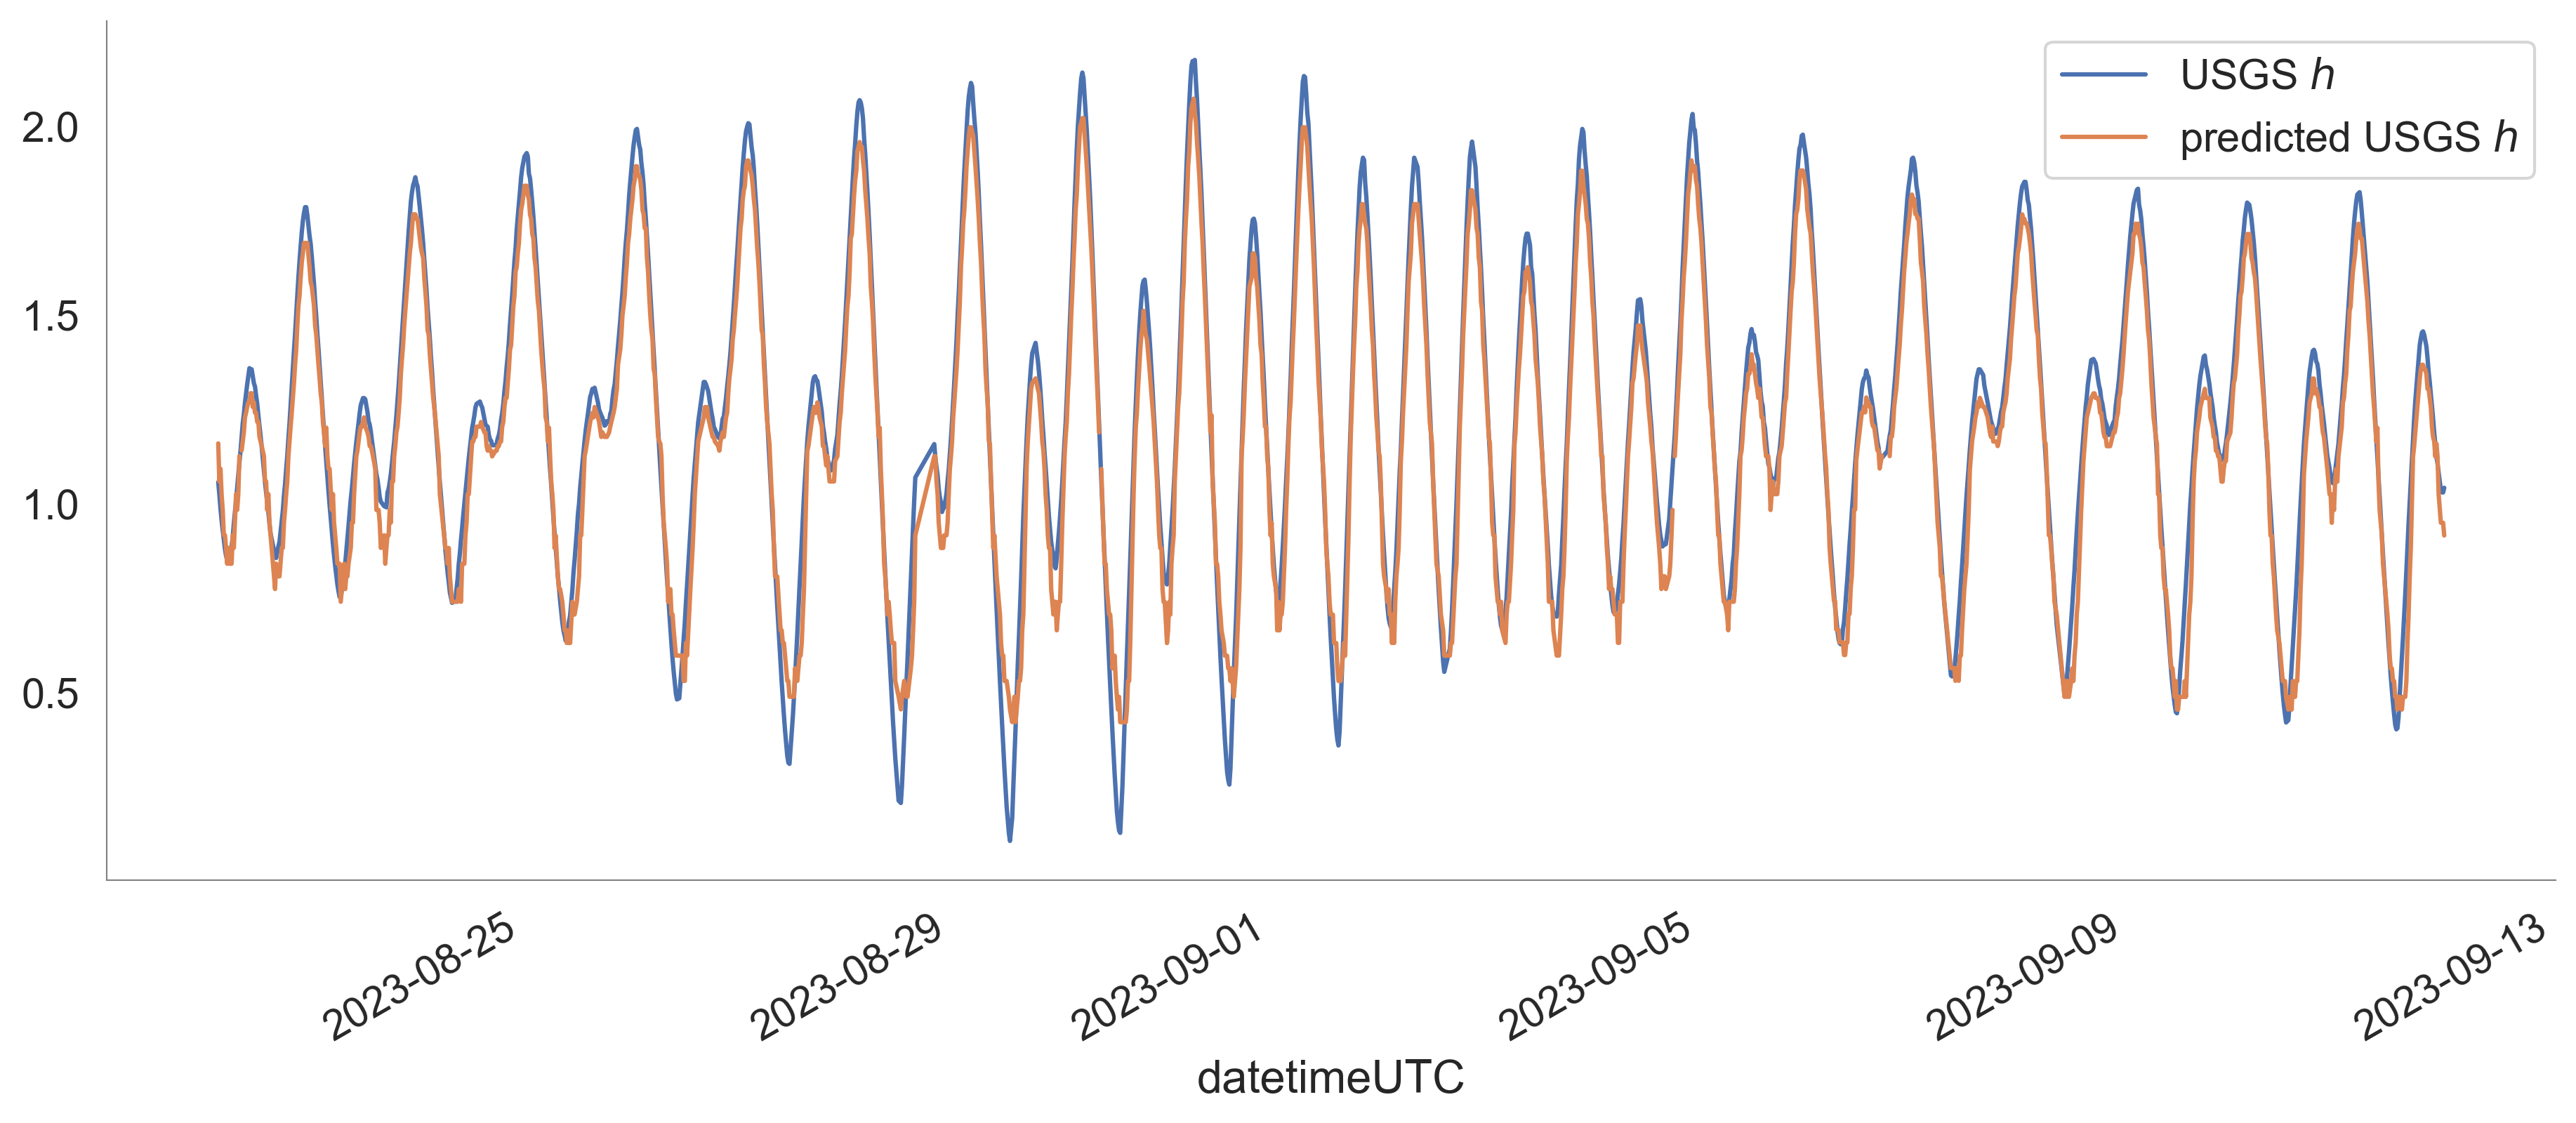

In [29]:
X1 = 'visitor_h'
X2 = 'Q'

df = hourly[-2000:].dropna()
df.loc[df.USGS_h < optimal_breakpoint, 'yhat'] = reg1.predict(df.loc[df.USGS_h < optimal_breakpoint][[X1, X2]])

df.loc[df.USGS_h > optimal_breakpoint, 'yhat'] = reg2.predict(df.loc[df.USGS_h > optimal_breakpoint][[X1, X2]])


# subset['Jenner h (regression)'] = res.predict(subset[['visitor_h']])
plt.figure(figsize = (15,6.))
df[['USGS_h', 'yhat']].plot(ax = plt.gca())

# plt.gca().set_yscale('log')
plt.legend(['USGS $h$', 'predicted USGS $h$'])



In [33]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# Prepare data
df = hourly[['USGS_h', 'Q', 'visitor_h']].dropna()
X = df[['Q', 'visitor_h']].values
y = df['USGS_h'].values
n_train= int(len(df)*0.8)
n_test= int(len(df)*0.2)
X_train, y_train = X[:n_train], y[:n_train]
X_test, y_test = X[n_train:], y[n_train:]
# # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Scaling data
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).reshape(-1)
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).reshape(-1)

# Reshape input to be 3D [samples, timesteps, features] for LSTM
X_train_scaled = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_scaled = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Define model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(1, 2)))
model.add(Dense(1))
model.compile(optimizer=Adam(learning_rate=0.02), loss='mse')

# Train model
model.fit(X_train_scaled, y_train_scaled, epochs=2, verbose=1)

Epoch 1/2
4554/4554 ━━━━━━━━━━━━━━━━━━━━ 4s 617us/step - loss: 0.0011
Epoch 2/2
4554/4554 ━━━━━━━━━━━━━━━━━━━━ 3s 616us/step - loss: 2.2075e-04


1139/1139 ━━━━━━━━━━━━━━━━━━━━ 1s 425us/step


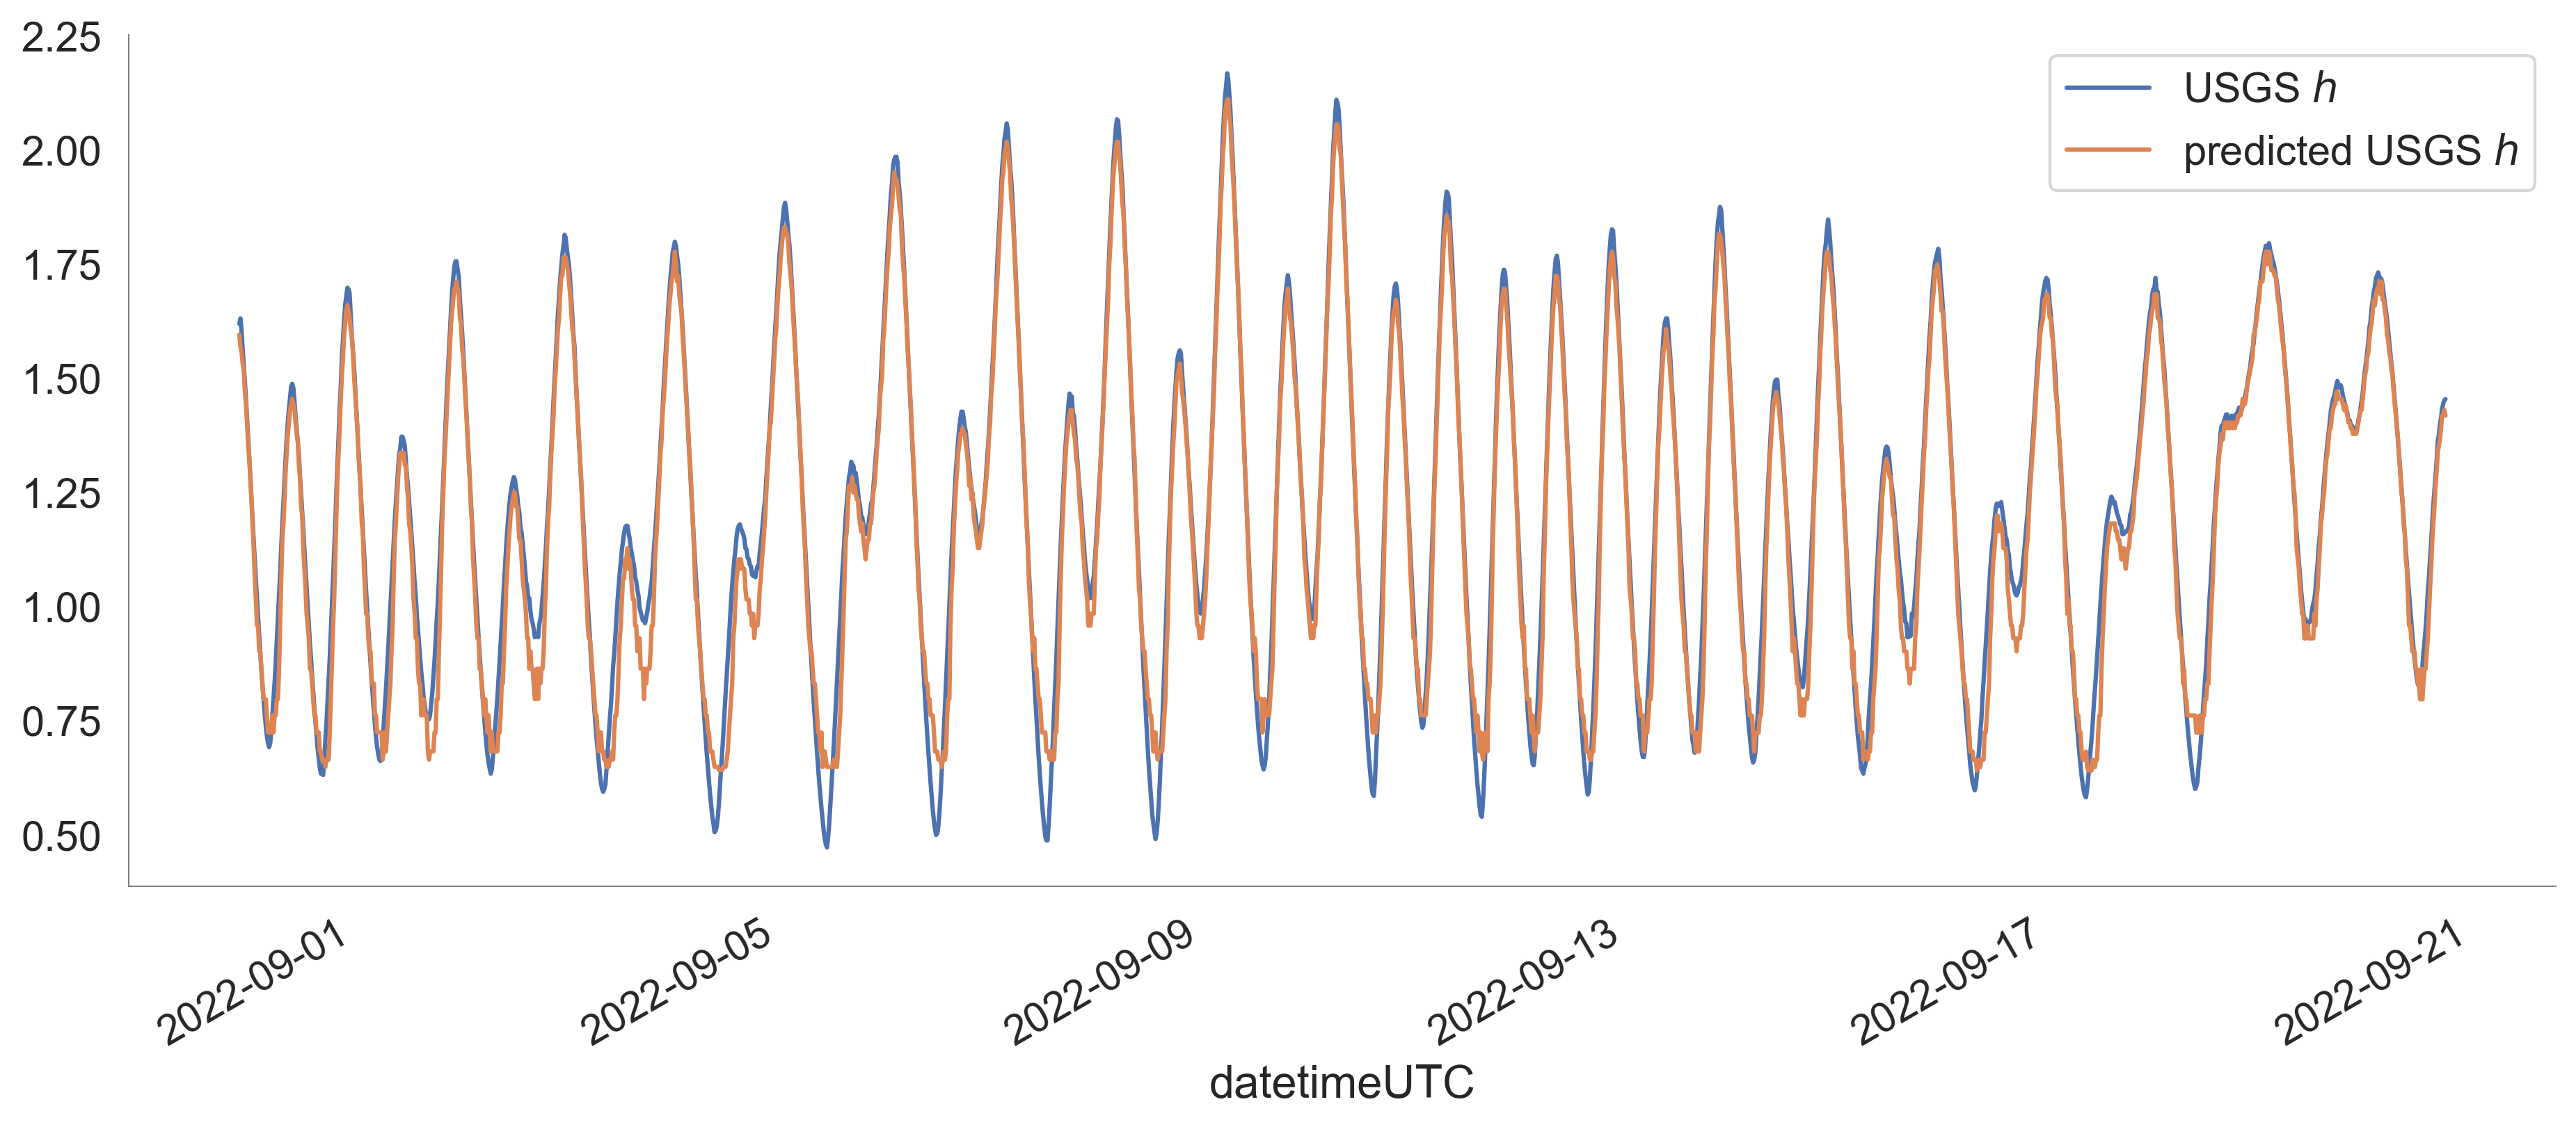

In [34]:
# Make predictions
y_pred = model.predict(X_test_scaled)

# Transform predictions back to original scale
y_pred_original = scaler_y.inverse_transform(y_pred)


test = df[n_train:]
test['hat_USGS_h'] = y_pred_original


# subset['Jenner h (regression)'] = res.predict(subset[['visitor_h']])
plt.figure(figsize = (15,6.))
test[['USGS_h', 'hat_USGS_h']][1000:3000].plot(ax = plt.gca())

# plt.gca().set_yscale('log')
plt.legend(['USGS $h$', 'predicted USGS $h$'])


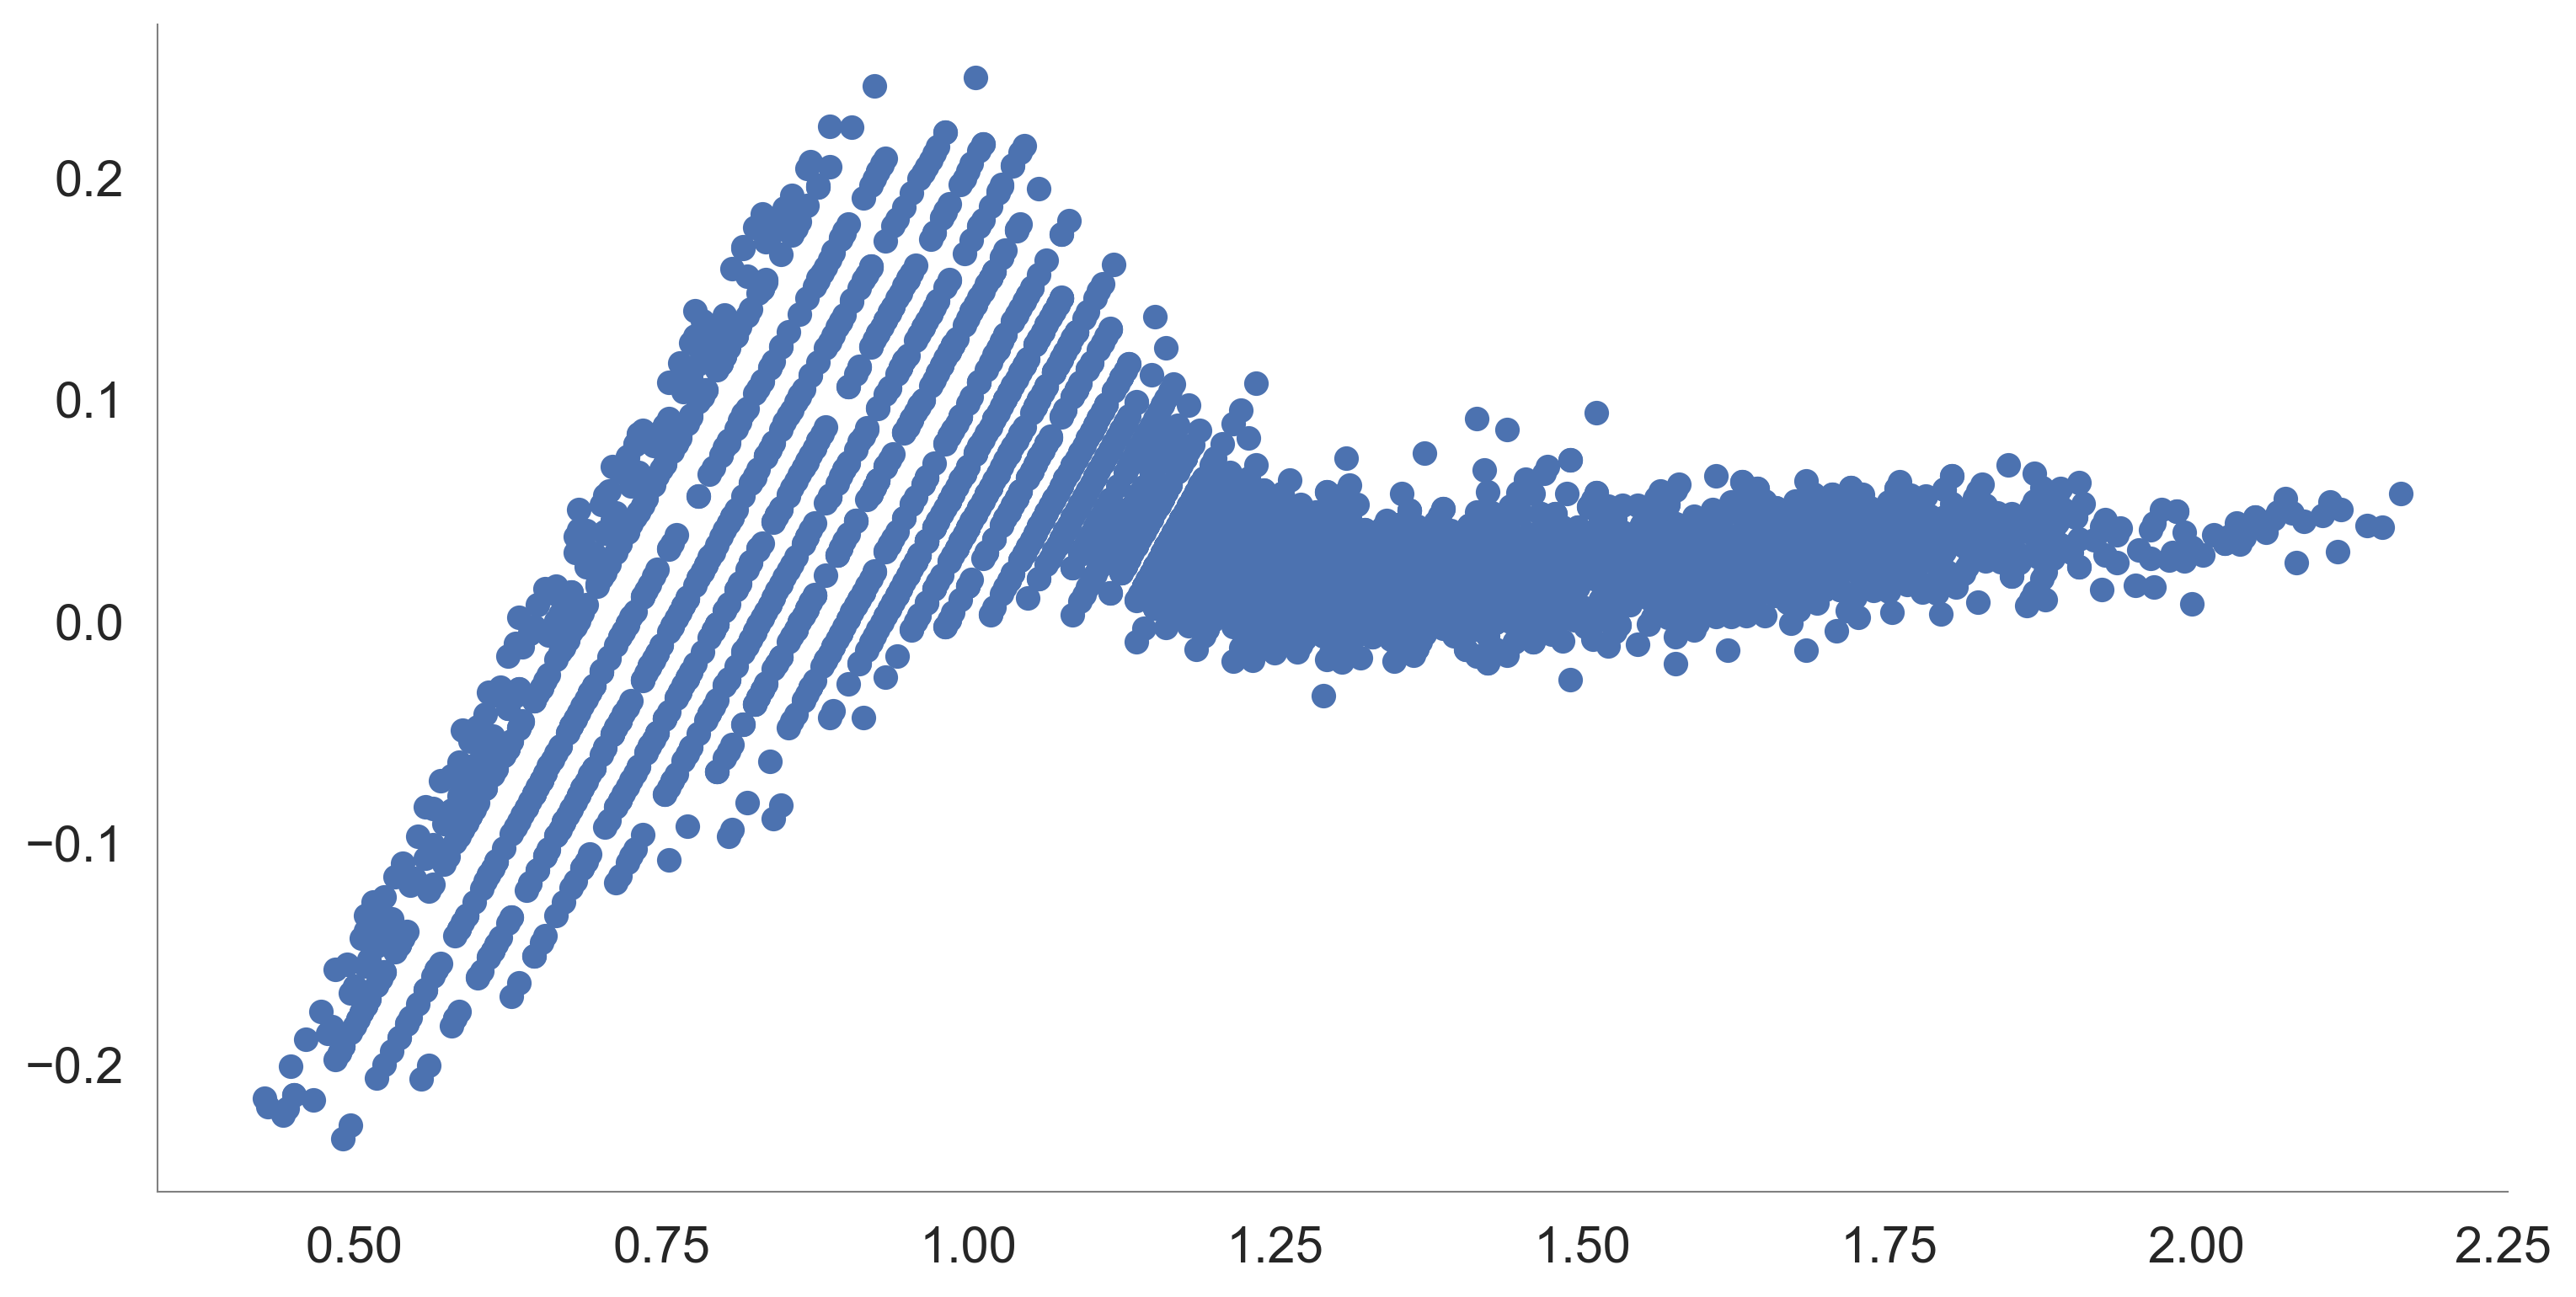

In [35]:
plt.scatter(y_test.reshape(-1)[:4000], y_test[:4000] - y_pred_original.reshape(-1)[:4000])